# Libraries

In [1]:
import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt #For plotting graphs
import seaborn as sns #For plotting graphs
sns.set_style("whitegrid")

from optbinning import OptimalBinning

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from optbinning import OptimalBinning
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

# Load Data

In [2]:
df_label = pd.read_csv("data/businesses.csv")
df_txns = pd.read_csv("data/transactions.csv")

# EDA

In [3]:
df_label.info()

<class 'pandas.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   business_token  328 non-null    str  
 1   is_bad          328 non-null    bool 
dtypes: bool(1), str(1)
memory usage: 3.0 KB


In [4]:
df_label_dedup = df_label.drop_duplicates()
df_label_dedup.info()

<class 'pandas.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   business_token  328 non-null    str  
 1   is_bad          328 non-null    bool 
dtypes: bool(1), str(1)
memory usage: 3.0 KB


In [5]:
# Sample Bad rate
df_label['is_bad'].value_counts(normalize=True)

default_rate = df_label['is_bad'].mean()

print(f"Default Rate: {default_rate:.2%}")

Default Rate: 84.15%


In [6]:
df_label['is_bad'].value_counts(dropna=False)

is_bad
True     276
False     52
Name: count, dtype: int64

### Comments

The fraud rate appears really high in comparision to a typical Fraud risk dataset. The Frauds == 'True' could be intentionally oversampled or is the label flipped? Inspecting the other variables can offer more information.

In [7]:
df_txns.info()

<class 'pandas.DataFrame'>
RangeIndex: 12658 entries, 0 to 12657
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   business_token           12658 non-null  str    
 1   transaction_date         12658 non-null  str    
 2   entry_type               12658 non-null  str    
 3   direction                12658 non-null  str    
 4   amount_cents             12658 non-null  int64  
 5   transaction_status       12658 non-null  str    
 6   internal_failure_reason  1289 non-null   str    
 7   vendor_name              12658 non-null  str    
 8   mcc                      9039 non-null   float64
 9   mcc_description          8682 non-null   str    
 10  merchant_country         9039 non-null   str    
 11  pos_data_type            8761 non-null   str    
 12  token_wallet_type        605 non-null    str    
 13  pos_data_attended        8761 non-null   object 
 14  pos_data_on_premise      8761 non

In [8]:
df_txns.nunique()

business_token               323
transaction_date           12316
entry_type                     6
direction                      2
amount_cents                6062
transaction_status             5
internal_failure_reason        6
vendor_name                 3754
mcc                          190
mcc_description              185
merchant_country              35
pos_data_type                  7
token_wallet_type              5
pos_data_attended              2
pos_data_on_premise            2
card_entry_mode                2
pin_entered                    2
pan_entry_mode                 7
card_network                   3
avs_result                     4
dtype: int64

In [9]:
df_txns.head()

,business_token,transaction_date,entry_type,direction,amount_cents,transaction_status,internal_failure_reason,vendor_name,mcc,mcc_description,merchant_country,pos_data_type,token_wallet_type,pos_data_attended,pos_data_on_premise,card_entry_mode,pin_entered,pan_entry_mode,card_network,avs_result
0,business_pGErY9hkzHwZ,2022-06-01 0:44:59,card,from,8338,SETTLED,NaN,"NEWGOV - NEWTON, MA",9399.0,Government Services ( Not Elsewhere Classified),USA,ECOMMERCE,NaN,False,True,NOT_PRESENT,False,KEY_ENTERED,MASTERCARD,MATCH
1,business_NrfhrFmh4xUq,2022-06-01 1:03:46,card,from,7217,SETTLED,NaN,HOLIDAY OIL 41,5542.0,Automated Fuel Dispensers,USA,POS_TERMINAL,NaN,True,True,PRESENT,True,ICC,MAESTRO,FAIL
2,business_sgTVjfkcmcAt,2022-06-01 1:51:26,atm,from,50300,SETTLED,NaN,QUIKTRIP #656,6011.0,Financial Institutions – Manual Cash Disbursem...,USA,ATM,NaN,False,False,PRESENT,True,ICC,MAESTRO,FAIL
3,business_sgTVjfkcmcAt,2022-06-01 2:05:52,card,from,10000,SETTLED,NaN,MURPHY EXPRESS 8843,5542.0,Automated Fuel Dispensers,USA,POS_TERMINAL,NaN,False,True,PRESENT,True,ICC,MASTERCARD,FAIL
4,business_sgTVjfkcmcAt,2022-06-01 2:49:50,card,from,15886,SETTLED,NaN,WM SUPERCENTER #313,5411.0,"Grocery Stores, Supermarkets",USA,POS_TERMINAL,NaN,True,True,PRESENT,False,ICC,MASTERCARD,FAIL


In [10]:
df_txns['transaction_status'].value_counts(dropna=False)

transaction_status
SETTLED     10916
DECLINED     1353
VOIDED        240
RETURNED      141
CANCELED        8
Name: count, dtype: int64

In [11]:
df_txns['entry_type'].value_counts(dropna=False)

entry_type
card                       8896
ach_external               2854
ach_internal                536
found_to_found_transfer     204
atm                         143
instant_debit                25
Name: count, dtype: int64

### Duplicate check

In [12]:
df_txns_dedup = df_txns.drop_duplicates()

print("Before dedup:", df_txns.shape[0])
print("After dedup:", df_txns_dedup.shape[0])
print("Duplicates removed:", df_txns.shape[0] - df_txns_dedup.shape[0])

Before dedup: 12658
After dedup: 12648
Duplicates removed: 10


In [13]:
df_txns = df_txns_dedup

In [14]:
dup_summary = (
    df_txns
    .groupby(["business_token", "transaction_date"])
    .size()
    .reset_index(name="row_count")
    .query("row_count > 1")
    .sort_values("row_count", ascending=False)
)
dup_summary

,business_token,transaction_date,row_count
11307,business_sgTVjfkcmcAt,2022-11-08 17:53:19,4
10957,business_sgTVjfkcmcAt,2022-09-18 17:44:30,3
10042,business_qGLGpBTexLMx,2022-09-06 11:02:39,3
11538,business_sgTVjfkcmcAt,2022-12-23 22:46:45,3
7087,business_eMsN3azWaHGB,2022-07-19 13:20:10,3
...,...,...,...
2718,business_HNhHRwbjdeRt,2022-10-04 10:51:17,2
2705,business_HNhHRwbjdeRt,2022-09-20 10:30:56,2
2695,business_HG4PuoZmtMhC,2022-11-14 23:48:06,2
2292,business_GthGNve4Ku76,2022-07-22 10:40:57,2


## Duplicate transactions - Case 1

In [15]:
df_txns[(df_txns['business_token'] == 'business_sgTVjfkcmcAt') & (df_txns['transaction_date'] == '2022-11-08 17:53:19')].head()

,business_token,transaction_date,entry_type,direction,amount_cents,transaction_status,internal_failure_reason,vendor_name,mcc,mcc_description,merchant_country,pos_data_type,token_wallet_type,pos_data_attended,pos_data_on_premise,card_entry_mode,pin_entered,pan_entry_mode,card_network,avs_result
9498,business_sgTVjfkcmcAt,2022-11-08 17:53:19,card,from,3895,SETTLED,NaN,eBay O*16-09313-77809,5311.0,Department Stores,USA,ECOMMERCE,NaN,False,True,NOT_PRESENT,False,UNKNOWN,MASTERCARD,MATCH
9499,business_sgTVjfkcmcAt,2022-11-08 17:53:19,card,from,3798,SETTLED,NaN,eBay O*16-09313-77809,5311.0,Department Stores,USA,ECOMMERCE,NaN,False,True,NOT_PRESENT,False,UNKNOWN,MASTERCARD,MATCH
9500,business_sgTVjfkcmcAt,2022-11-08 17:53:19,card,from,3899,SETTLED,NaN,eBay O*16-09313-77809,5311.0,Department Stores,USA,ECOMMERCE,NaN,False,True,NOT_PRESENT,False,UNKNOWN,MASTERCARD,MATCH
9501,business_sgTVjfkcmcAt,2022-11-08 17:53:19,card,from,3495,SETTLED,NaN,eBay O*16-09313-77809,5311.0,Department Stores,USA,ECOMMERCE,NaN,False,True,NOT_PRESENT,False,UNKNOWN,MASTERCARD,MATCH


### Comment
Same business and timestamp, all are settled txns, but slightly different amounts. Entry type = 'Card' Every other field is same. Is there truncation in the timestamp?

## Duplicate transactions - Case 2

In [16]:
df_txns[(df_txns['business_token'] == 'business_qGLGpBTexLMx') & (df_txns['transaction_date'] == '2022-09-06 11:02:39')].head()

,business_token,transaction_date,entry_type,direction,amount_cents,transaction_status,internal_failure_reason,vendor_name,mcc,mcc_description,merchant_country,pos_data_type,token_wallet_type,pos_data_attended,pos_data_on_premise,card_entry_mode,pin_entered,pan_entry_mode,card_network,avs_result
4718,business_qGLGpBTexLMx,2022-09-06 11:02:39,ach_external,to,140000,SETTLED,NaN,xMnr70nezv5mnfpBcXPwXe/gXhAfIuFE6wPDwDIQrJA=,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4719,business_qGLGpBTexLMx,2022-09-06 11:02:39,ach_external,to,17,SETTLED,NaN,xMnr70nezv5mnfpBcXPwXe/gXhAfIuFE6wPDwDIQrJA=,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4720,business_qGLGpBTexLMx,2022-09-06 11:02:39,ach_external,to,27,SETTLED,NaN,xMnr70nezv5mnfpBcXPwXe/gXhAfIuFE6wPDwDIQrJA=,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Comment
All are settled txns, same timestamp, entry_type = 'ach' and 2 amounts < $1 look like micro deposits

In [17]:
label_biz = set(df_label["business_token"].unique())
txns_biz = set(df_txns["business_token"].unique())

biz_in_both = label_biz.intersection(txns_biz)
biz_only_label = label_biz.difference(txns_biz)
biz_only_txns = txns_biz.difference(label_biz)

print("Businesses in both:", len(biz_in_both))
print("Businesses only in df_label:", len(biz_only_label))
print("Businesses only in df_txns:", len(biz_only_txns))

Businesses in both: 323
Businesses only in df_label: 5
Businesses only in df_txns: 0


### Comments

The label dataset contains 328 unique businesses, while the transaction dataset contains 323 unique businesses. This means there are 5 businesses present in the label dataset that are not present in the transaction dataset.

> **Note:** 5 businesses have an `is_bad` label but do not appear in the transactions file. These businesses are excluded from all downstream analysis and modelling since there is no transaction history to learn from.

In [18]:
# Merge the dataframes

df_combined = pd.merge(df_txns,df_label,how='left',on='business_token')

In [19]:
df_combined['is_bad'].value_counts(dropna=False)

is_bad
False    9301
True     3347
Name: count, dtype: int64

In [20]:
df_combined[(df_combined['business_token'] == 'business_qGLGpBTexLMx')].head(100)

,business_token,transaction_date,entry_type,direction,amount_cents,transaction_status,internal_failure_reason,vendor_name,mcc,mcc_description,...,pos_data_type,token_wallet_type,pos_data_attended,pos_data_on_premise,card_entry_mode,pin_entered,pan_entry_mode,card_network,avs_result,is_bad
4715,business_qGLGpBTexLMx,2022-09-06 11:02:39,ach_external,to,140000,SETTLED,NaN,xMnr70nezv5mnfpBcXPwXe/gXhAfIuFE6wPDwDIQrJA=,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
4716,business_qGLGpBTexLMx,2022-09-06 11:02:39,ach_external,to,17,SETTLED,NaN,xMnr70nezv5mnfpBcXPwXe/gXhAfIuFE6wPDwDIQrJA=,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
4717,business_qGLGpBTexLMx,2022-09-06 11:02:39,ach_external,to,27,SETTLED,NaN,xMnr70nezv5mnfpBcXPwXe/gXhAfIuFE6wPDwDIQrJA=,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
4733,business_qGLGpBTexLMx,2022-09-06 11:12:01,ach_external,from,17,SETTLED,NaN,xMnr70nezv5mnfpBcXPwXe/gXhAfIuFE6wPDwDIQrJA=,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
4734,business_qGLGpBTexLMx,2022-09-06 11:12:01,ach_external,from,27,SETTLED,NaN,xMnr70nezv5mnfpBcXPwXe/gXhAfIuFE6wPDwDIQrJA=,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
4767,business_qGLGpBTexLMx,2022-09-06 19:05:06,card,from,37000,SETTLED,NaN,MICHAEL KORS - 704,5621.0,Women’s Ready-to-Wear Stores,...,POS_TERMINAL,NaN,True,True,PRESENT,False,CONTACTLESS,MASTERCARD,FAIL,True
4771,business_qGLGpBTexLMx,2022-09-06 20:05:28,card,from,106000,DECLINED,INSUFFICIENT_FUNDS,COACH INC 5051,5631.0,Women’s Accessory and Specialty Shops,...,POS_TERMINAL,APPLE_PAY,True,True,PRESENT,False,CONTACTLESS,MASTERCARD,FAIL,True
4772,business_qGLGpBTexLMx,2022-09-06 20:09:13,card,from,103000,SETTLED,NaN,COACH INC 5051,5631.0,Women’s Accessory and Specialty Shops,...,POS_TERMINAL,NaN,True,True,PRESENT,False,CONTACTLESS,MASTERCARD,FAIL,True
4796,business_qGLGpBTexLMx,2022-09-07 11:01:31,ach_external,to,4,SETTLED,NaN,4tgPKtHiTtJAWYmIzRs7g8+RXZwNyW3dDMghKjNdfoQ=,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
4797,business_qGLGpBTexLMx,2022-09-07 11:01:32,ach_external,to,6,SETTLED,NaN,4tgPKtHiTtJAWYmIzRs7g8+RXZwNyW3dDMghKjNdfoQ=,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


In [21]:
# Date range per business from df_combined
df_combined['transaction_date'] = pd.to_datetime(df_combined['transaction_date'])

biz_range = df_combined.groupby('business_token').agg(
    first=('transaction_date', 'min'),
    last=('transaction_date', 'max'),
    is_bad=('is_bad', 'first')
)
biz_range['range_days'] = (biz_range['last'] - biz_range['first']).dt.days

r = biz_range['range_days']
print(f"Min:  {r.min()} days")
print(f"Max:  {r.max()} days")
print(f"Mean: {r.mean():.1f} days")
print(f"Mode: {r.mode().values} days")
print()
r.describe(percentiles=[.25, .5, .75, .9])

Min:  0 days
Max:  213 days
Mean: 34.9 days
Mode: [0] days



count    323.000000
mean      34.882353
std       65.826507
min        0.000000
25%        0.000000
50%        4.000000
75%       28.500000
90%      181.400000
max      213.000000
Name: range_days, dtype: float64

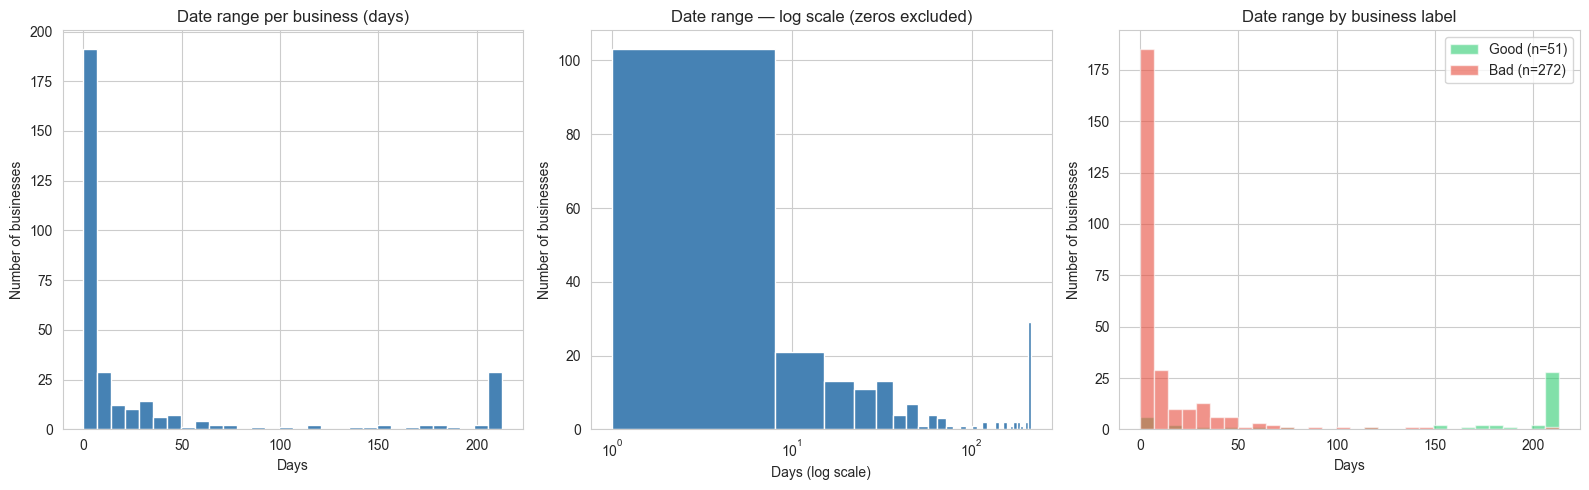

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(r, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Date range per business (days)')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of businesses')

axes[1].hist(r[r > 0], bins=30, color='steelblue', edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_title('Date range — log scale (zeros excluded)')
axes[1].set_xlabel('Days (log scale)')
axes[1].set_ylabel('Number of businesses')

for label, grp in biz_range.groupby('is_bad'):
    axes[2].hist(grp['range_days'], bins=30, alpha=0.6,
                 label=f"{'Bad' if label else 'Good'} (n={len(grp)})",
                 color='#e74c3c' if label else '#2ecc71', edgecolor='white')
axes[2].set_title('Date range by business label')
axes[2].set_xlabel('Days')
axes[2].set_ylabel('Number of businesses')
axes[2].legend()

plt.tight_layout()
plt.show()


In [23]:
def run_basic_eda(df, target_col=None):
    print("Shape:", df.shape)
    
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null_count": df.notna().sum(),
        "missing_count": df.isna().sum(),
        "missing_rate": df.isna().mean(),
        "unique_count": df.nunique(dropna=True),
        "unique_rate": df.nunique(dropna=True) / len(df)
    }).sort_values("unique_count", ascending=False)
    
    display(summary)
    
    numeric_cols = df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
    cat_cols = df.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
    
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)
    if target_col in cat_cols:
        cat_cols.remove(target_col)
    
    print("Numeric columns:", numeric_cols)
    print("Categorical columns:", cat_cols)
    
    if len(numeric_cols) > 0:
        display(
            df[numeric_cols].describe(
                percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
            ).T
        )
    
    for col in cat_cols:
        print(f"\nFrequency table for {col}")
        temp = (
            df[col]
            .value_counts(dropna=False)
            .rename_axis(col)
            .reset_index(name="count")
        )
        temp["percent"] = temp["count"] / len(df) * 100
        display(temp.head(30))
    
    if target_col:
        print("\nTarget bad rate:")
        print(df[target_col].mean())

# Assistant
Here's the refactored version of the selected code with improved structure, type hints, docstrings, and maintainability:


In [24]:
from typing import Optional, List, Tuple
import pandas as pd
from IPython.display import display

def run_basic_eda(df: pd.DataFrame, target_col: Optional[str] = None) -> None:
    """
    Perform basic exploratory data analysis on a DataFrame.
    
    This function provides a comprehensive overview of the dataset including:
    - Dataset shape and column summary statistics
    - Identification of numeric and categorical columns
    - Descriptive statistics for numeric columns
    - Frequency tables for categorical columns
    - Target variable analysis (if specified)
    
    Args:
        df (pd.DataFrame): The input DataFrame to analyze
        target_col (Optional[str]): Name of the target column for analysis.
                                   If provided, it will be excluded from feature analysis
                                   and its mean will be calculated. Defaults to None.
    
    Returns:
        None: This function prints and displays results directly
    """
    _print_dataset_shape(df)
    _display_column_summary(df)
    
    numeric_cols, categorical_cols = _identify_column_types(df, target_col)
    
    print(f"Numeric columns: {numeric_cols}")
    print(f"Categorical columns: {categorical_cols}")
    
    _display_numeric_statistics(df, numeric_cols)
    _display_categorical_frequencies(df, categorical_cols)
    _display_target_analysis(df, target_col)


def _print_dataset_shape(df: pd.DataFrame) -> None:
    """Print the shape of the dataset."""
    print(f"Shape: {df.shape}")


def _display_column_summary(df: pd.DataFrame) -> None:
    """Display a comprehensive summary of all columns."""
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null_count": df.notna().sum(),
        "missing_count": df.isna().sum(),
        "missing_rate": df.isna().mean(),
        "unique_count": df.nunique(dropna=True),
        "unique_rate": df.nunique(dropna=True) / len(df)
    }).sort_values("unique_count", ascending=False)
    
    display(summary)


def _identify_column_types(df: pd.DataFrame, target_col: Optional[str]) -> Tuple[List[str], List[str]]:
    """
    Identify numeric and categorical columns, excluding the target column.
    
    Args:
        df (pd.DataFrame): The input DataFrame
        target_col (Optional[str]): Target column to exclude from analysis
    
    Returns:
        Tuple[List[str], List[str]]: Lists of numeric and categorical column names
    """
    numeric_cols = df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
    categorical_cols = df.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
    
    # Remove target column from feature lists if it exists
    if target_col:
        if target_col in numeric_cols:
            numeric_cols.remove(target_col)
        if target_col in categorical_cols:
            categorical_cols.remove(target_col)
    
    return numeric_cols, categorical_cols


def _display_numeric_statistics(df: pd.DataFrame, numeric_cols: List[str]) -> None:
    """Display descriptive statistics for numeric columns."""
    if len(numeric_cols) > 0:
        percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
        display(df[numeric_cols].describe(percentiles=percentiles).T)


def _display_categorical_frequencies(df: pd.DataFrame, categorical_cols: List[str]) -> None:
    """Display frequency tables for categorical columns."""
    for col in categorical_cols:
        print(f"\nFrequency table for {col}")
        frequency_table = _create_frequency_table(df, col)
        display(frequency_table.head(30))


def _create_frequency_table(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """
    Create a frequency table for a categorical column.
    
    Args:
        df (pd.DataFrame): The input DataFrame
        column (str): Column name to analyze
    
    Returns:
        pd.DataFrame: Frequency table with counts and percentages
    """
    frequency_table = (
        df[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="count")
    )
    frequency_table["percent"] = frequency_table["count"] / len(df) * 100
    return frequency_table


def _display_target_analysis(df: pd.DataFrame, target_col: Optional[str]) -> None:
    """Display target variable analysis if target column is specified."""
    if target_col:
        print(f"\nTarget bad rate:")
        print(f"{df[target_col].mean():.4f}")

# User
Can you add bad rate to the categorical variables

# Assistant
Here's the updated refactored code with bad rate analysis added to categorical variables:


In [25]:
import numpy as np
import pandas as pd

def run_basic_eda(
    df,
    target_col=None,
    amount_col="amount_cents",
    direction_col="direction",
    outgoing_value="from"
):
    print("Shape:", df.shape)

    has_target = target_col is not None and target_col in df.columns
    has_amount = amount_col in df.columns
    has_direction = direction_col in df.columns
    has_outgoing = has_amount and has_direction

    df_eda = df.copy()

    if has_target:
        df_eda[target_col] = pd.to_numeric(df_eda[target_col], errors="coerce")

    if has_amount:
        df_eda[amount_col] = pd.to_numeric(df_eda[amount_col], errors="coerce")
        df_eda["amount_dollars"] = df_eda[amount_col] / 100

    if has_outgoing:
        df_eda["is_outgoing"] = (
            df_eda[direction_col]
            .astype(str)
            .str.lower()
            .eq(str(outgoing_value).lower())
        )

        df_eda["outgoing_amount_dollars"] = np.where(
            df_eda["is_outgoing"],
            df_eda["amount_dollars"],
            0
        )

        if has_target:
            df_eda["bad_outgoing_amount_dollars"] = np.where(
                (df_eda[target_col] == 1) & (df_eda["is_outgoing"]),
                df_eda["amount_dollars"],
                0
            )

            df_eda["good_outgoing_amount_dollars"] = np.where(
                (df_eda[target_col] == 0) & (df_eda["is_outgoing"]),
                df_eda["amount_dollars"],
                0
            )

    summary = pd.DataFrame({
        "dtype": df_eda.dtypes.astype(str),
        "non_null_count": df_eda.notna().sum(),
        "missing_count": df_eda.isna().sum(),
        "missing_rate": df_eda.isna().mean(),
        "unique_count": df_eda.nunique(dropna=True),
        "unique_rate": df_eda.nunique(dropna=True) / len(df_eda)
    })

    if has_target:
        bad_rate_non_missing = {}
        bad_rate_missing = {}

        for col in df_eda.columns:
            if col == target_col:
                bad_rate_non_missing[col] = np.nan
                bad_rate_missing[col] = np.nan
                continue

            non_missing_mask = df_eda[col].notna()
            missing_mask = df_eda[col].isna()

            bad_rate_non_missing[col] = (
                df_eda.loc[non_missing_mask, target_col].mean()
                if non_missing_mask.sum() > 0
                else np.nan
            )

            bad_rate_missing[col] = (
                df_eda.loc[missing_mask, target_col].mean()
                if missing_mask.sum() > 0
                else np.nan
            )

        summary["bad_rate_non_missing"] = pd.Series(bad_rate_non_missing)
        summary["bad_rate_missing"] = pd.Series(bad_rate_missing)

    summary = summary.sort_values("unique_count", ascending=False)
    display(summary)

    numeric_cols = df_eda.select_dtypes(
        include=["int64", "float64", "int32", "float32", "int16", "float16"]
    ).columns.tolist()

    cat_cols = df_eda.select_dtypes(
        include=["object", "string", "category", "bool"]
    ).columns.tolist()

    if has_target and target_col in numeric_cols:
        numeric_cols.remove(target_col)

    if has_target and target_col in cat_cols:
        cat_cols.remove(target_col)

    print("Numeric columns:", numeric_cols)
    print("Categorical columns:", cat_cols)

    if len(numeric_cols) > 0:
        display(
            df_eda[numeric_cols].describe(
                percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
            ).T
        )

    for col in cat_cols:
        print(f"\nFrequency table for {col}")

        if has_target:
            temp = (
                df_eda
                .groupby(col, dropna=False)
                .agg(
                    count=(col, "size"),
                    bad_count=(target_col, "sum"),
                    bad_rate=(target_col, "mean")
                )
                .reset_index()
            )

            temp["good_count"] = temp["count"] - temp["bad_count"]
            temp["good_rate"] = 1 - temp["bad_rate"]
            temp["percent"] = temp["count"] / len(df_eda) * 100

            if has_outgoing:
                sev = (
                    df_eda
                    .groupby(col, dropna=False)
                    .agg(
                        outgoing_txn_count=("is_outgoing", "sum"),
                        outgoing_total_dollars=("outgoing_amount_dollars", "sum"),
                        bad_outgoing_total_dollars=("bad_outgoing_amount_dollars", "sum"),
                        good_outgoing_total_dollars=("good_outgoing_amount_dollars", "sum")
                    )
                    .reset_index()
                )

                bad_outgoing_count = (
                    df_eda
                    .assign(
                        bad_outgoing_flag=lambda x: (
                            (x[target_col] == 1) & (x["is_outgoing"])
                        ).astype(int)
                    )
                    .groupby(col, dropna=False)
                    .agg(
                        bad_outgoing_txn_count=("bad_outgoing_flag", "sum")
                    )
                    .reset_index()
                )

                sev = sev.merge(bad_outgoing_count, on=col, how="left")
                temp = temp.merge(sev, on=col, how="left")

                temp["outgoing_avg_dollars"] = np.where(
                    temp["outgoing_txn_count"] > 0,
                    temp["outgoing_total_dollars"] / temp["outgoing_txn_count"],
                    np.nan
                )

                temp["bad_outgoing_avg_dollars"] = np.where(
                    temp["bad_outgoing_txn_count"] > 0,
                    temp["bad_outgoing_total_dollars"] / temp["bad_outgoing_txn_count"],
                    np.nan
                )

                temp["bad_outgoing_share_of_total_outgoing"] = np.where(
                    temp["outgoing_total_dollars"] > 0,
                    temp["bad_outgoing_total_dollars"] / temp["outgoing_total_dollars"],
                    np.nan
                )

                dollar_cols = [
                    "outgoing_total_dollars",
                    "outgoing_avg_dollars",
                    "bad_outgoing_total_dollars",
                    "bad_outgoing_avg_dollars",
                    "good_outgoing_total_dollars"
                ]

                for dollar_col in dollar_cols:
                    if dollar_col in temp.columns:
                        temp[dollar_col] = temp[dollar_col].round(2)

                temp = temp[
                    [
                        col,
                        "count",
                        "percent",
                        "bad_count",
                        "bad_rate",
                        "bad_outgoing_avg_dollars",
                        "bad_outgoing_share_of_total_outgoing",
                        "good_count",
                        "good_rate",
                        "outgoing_txn_count",
                        "outgoing_total_dollars",
                        "outgoing_avg_dollars",
                        "bad_outgoing_txn_count",
                        "bad_outgoing_total_dollars",
                        "good_outgoing_total_dollars"
                    ]
                ].sort_values("bad_outgoing_total_dollars", ascending=False)

            else:
                temp = temp[
                    [
                        col,
                        "count",
                        "percent",
                        "bad_count",
                        "bad_rate",
                        "good_count",
                        "good_rate"
                    ]
                ].sort_values("count", ascending=False)

        else:
            temp = (
                df_eda[col]
                .value_counts(dropna=False)
                .rename_axis(col)
                .reset_index(name="count")
            )

            temp["percent"] = temp["count"] / len(df_eda) * 100

        display(temp.head(30))

    if has_target:
        print("\nTarget bad rate:")
        print(df_eda[target_col].mean())

    if has_target and has_outgoing:
        print("\nFraud severity summary based on outgoing dollars:")

        total_outgoing = df_eda["outgoing_amount_dollars"].sum()
        bad_outgoing = df_eda["bad_outgoing_amount_dollars"].sum()
        good_outgoing = df_eda["good_outgoing_amount_dollars"].sum()

        bad_outgoing_txns = (
            (df_eda[target_col] == 1) & (df_eda["is_outgoing"])
        ).sum()

        all_outgoing_txns = df_eda["is_outgoing"].sum()

        severity_summary = pd.DataFrame({
            "metric": [
                "total_outgoing_dollars",
                "bad_outgoing_total_dollars",
                "good_outgoing_total_dollars",
                "bad_outgoing_share_of_total_outgoing",
                "all_outgoing_txn_count",
                "bad_outgoing_txn_count",
                "avg_outgoing_dollars",
                "bad_avg_outgoing_dollars"
            ],
            "value": [
                total_outgoing,
                bad_outgoing,
                good_outgoing,
                bad_outgoing / total_outgoing if total_outgoing > 0 else np.nan,
                all_outgoing_txns,
                bad_outgoing_txns,
                total_outgoing / all_outgoing_txns if all_outgoing_txns > 0 else np.nan,
                bad_outgoing / bad_outgoing_txns if bad_outgoing_txns > 0 else np.nan
            ]
        })

        dollar_metrics = [
            "total_outgoing_dollars",
            "bad_outgoing_total_dollars",
            "good_outgoing_total_dollars",
            "avg_outgoing_dollars",
            "bad_avg_outgoing_dollars"
        ]

        severity_summary.loc[
            severity_summary["metric"].isin(dollar_metrics),
            "value"
        ] = severity_summary.loc[
            severity_summary["metric"].isin(dollar_metrics),
            "value"
        ].round(2)

        display(severity_summary)

In [26]:
run_basic_eda(df_combined, target_col='is_bad')

Shape: (12648, 21)


,dtype,non_null_count,missing_count,missing_rate,unique_count,unique_rate,bad_rate_non_missing,bad_rate_missing
transaction_date,datetime64[us],12648,0,0.000000,12316,0.973751,0.264627,NaN
amount_cents,int64,12648,0,0.000000,6062,0.479285,0.264627,NaN
amount_dollars,float64,12648,0,0.000000,6062,0.479285,0.264627,NaN
outgoing_amount_dollars,float64,12648,0,0.000000,4572,0.361480,0.264627,NaN
good_outgoing_amount_dollars,float64,12648,0,0.000000,3983,0.314911,0.264627,NaN
vendor_name,str,12648,0,0.000000,3754,0.296806,0.264627,NaN
bad_outgoing_amount_dollars,float64,12648,0,0.000000,858,0.067837,0.264627,NaN
business_token,str,12648,0,0.000000,323,0.025538,0.264627,NaN
mcc,float64,9034,3614,0.285737,190,0.015022,0.266327,0.260376
mcc_description,str,8677,3971,0.313963,185,0.014627,0.261957,0.270461


Numeric columns: ['amount_cents', 'mcc', 'amount_dollars', 'outgoing_amount_dollars', 'bad_outgoing_amount_dollars', 'good_outgoing_amount_dollars']
Categorical columns: ['business_token', 'entry_type', 'direction', 'transaction_status', 'internal_failure_reason', 'vendor_name', 'mcc_description', 'merchant_country', 'pos_data_type', 'token_wallet_type', 'pos_data_attended', 'pos_data_on_premise', 'card_entry_mode', 'pin_entered', 'pan_entry_mode', 'card_network', 'avs_result', 'is_outgoing']


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
amount_cents,12648.0,65057.226439,179316.607854,0.0,7.00,108.00,1898.7500,9693.00,53862.5000,300000.0000,824885.8000,7500000.0
mcc,9034.0,5889.413327,1041.975782,742.0,4114.30,4215.00,5411.0000,5734.00,5968.0000,7735.0500,9402.0000,9402.0
amount_dollars,12648.0,650.572264,1793.166079,0.0,0.07,1.08,18.9875,96.93,538.6250,3000.0000,8248.8580,75000.0
outgoing_amount_dollars,12648.0,339.577407,942.597806,0.0,0.00,0.00,3.2675,31.99,216.4625,1506.5800,4449.4753,20625.0
bad_outgoing_amount_dollars,12648.0,143.180902,613.101271,0.0,0.00,0.00,0.0000,0.00,0.0000,1000.0000,2897.9085,16200.0
good_outgoing_amount_dollars,12648.0,196.396505,754.216388,0.0,0.00,0.00,0.0000,9.99,73.1500,900.8995,3500.0000,20625.0



Frequency table for business_token


...

,avs_result,count,percent,bad_count,bad_rate,bad_outgoing_avg_dollars,bad_outgoing_share_of_total_outgoing,good_count,good_rate,outgoing_txn_count,outgoing_total_dollars,outgoing_avg_dollars,bad_outgoing_txn_count,bad_outgoing_total_dollars,good_outgoing_total_dollars
0,FAIL,5204,41.144845,1695,0.325711,718.43,0.724390,3509,0.674289,4957,1557086.56,314.12,1570,1127938.70,429147.86
4,NaN,3893,30.779570,978,0.251220,1522.67,0.286139,2915,0.748780,1554,2192427.01,1410.83,412,627339.82,1565087.19
1,MATCH,1871,14.792853,359,0.191876,104.46,0.114353,1512,0.808124,1864,325187.45,174.46,356,37186.11,288001.34
3,MATCH_ZIP_ONLY,1639,12.958571,315,0.192190,58.69,0.085585,1324,0.807810,1638,216013.23,131.88,315,18487.42,197525.81
2,MATCH_ADDRESS_ONLY,41,0.324162,0,0.000000,NaN,0.000000,41,1.000000,41,4260.80,103.92,0,0.00,4260.80



Frequency table for is_outgoing


,is_outgoing,count,percent,bad_count,bad_rate,bad_outgoing_avg_dollars,bad_outgoing_share_of_total_outgoing,good_count,good_rate,outgoing_txn_count,outgoing_total_dollars,outgoing_avg_dollars,bad_outgoing_txn_count,bad_outgoing_total_dollars,good_outgoing_total_dollars
1,True,10054,79.490829,2653,0.263875,682.61,0.421644,7401,0.736125,10054,4294975.05,427.19,2653,1810952.05,2484023.0
0,False,2594,20.509171,694,0.267540,NaN,NaN,1900,0.732460,0,0.00,NaN,0,0.00,0.0



Target bad rate:
0.26462681846932323

Fraud severity summary based on outgoing dollars:


,metric,value
0,total_outgoing_dollars,4.294975e+06
1,bad_outgoing_total_dollars,1.810952e+06
2,good_outgoing_total_dollars,2.484023e+06
3,bad_outgoing_share_of_total_outgoing,4.216444e-01
4,all_outgoing_txn_count,1.005400e+04
5,bad_outgoing_txn_count,2.653000e+03
6,avg_outgoing_dollars,4.271900e+02
7,bad_avg_outgoing_dollars,6.826100e+02


## Visualizations

Run the cells below after loading data and creating `df_combined`.

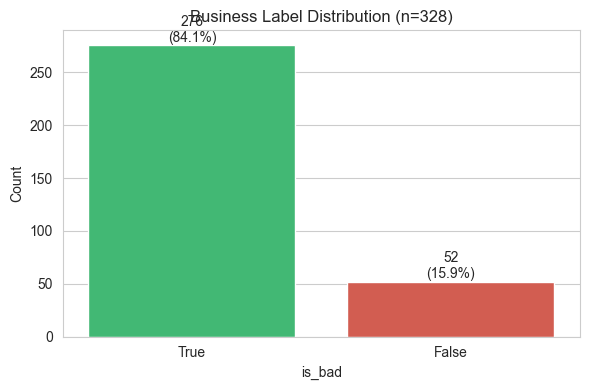

In [27]:
# 1. Label distribution
fig, ax = plt.subplots(figsize=(6, 4))
counts = df_label["is_bad"].value_counts()
sns.barplot(x=counts.index.astype(str), y=counts.values, hue=counts.index.astype(str),
            palette=["#2ecc71", "#e74c3c"], legend=False, ax=ax)
ax.set_title("Business Label Distribution (n=328)")
ax.set_xlabel("is_bad")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, f"{v}\n({v/len(df_label):.1%})", ha="center")
plt.tight_layout()
plt.show()

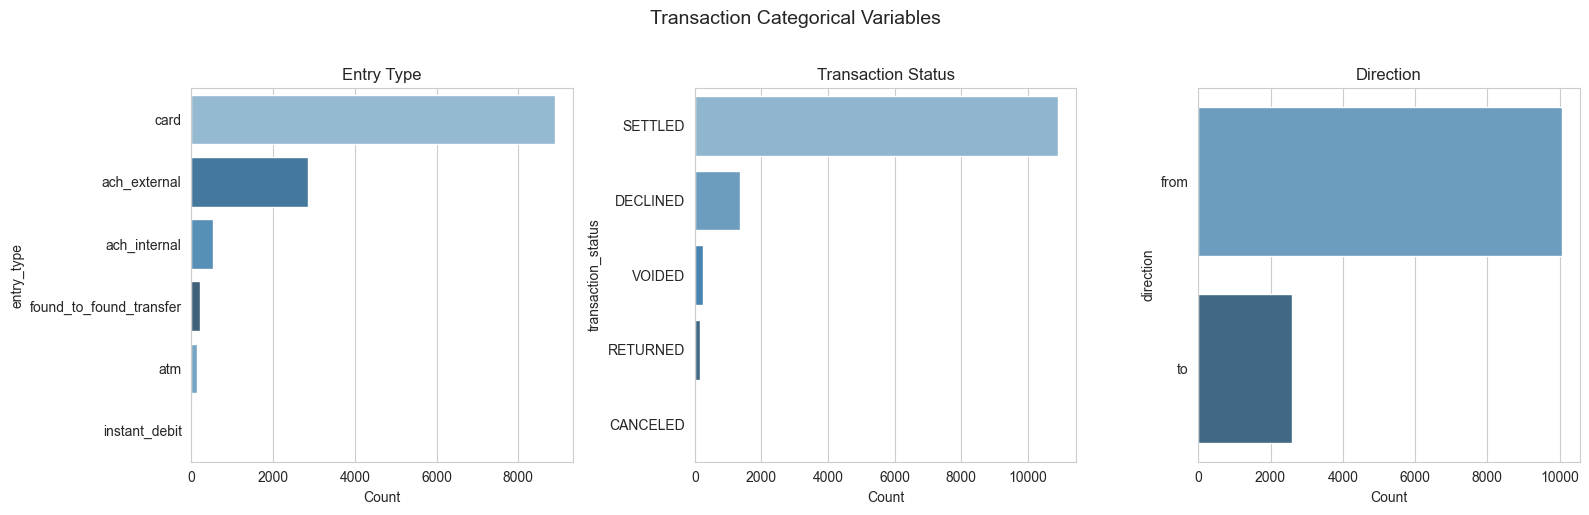

In [28]:
# 2. Transaction categorical variables
cat_cols = ["entry_type", "transaction_status", "direction"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, cat_cols):
    order = df_txns[col].value_counts().index
    sns.countplot(data=df_txns, y=col, order=order, hue=col, palette="Blues_d", legend=False, ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Count")
plt.suptitle("Transaction Categorical Variables", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

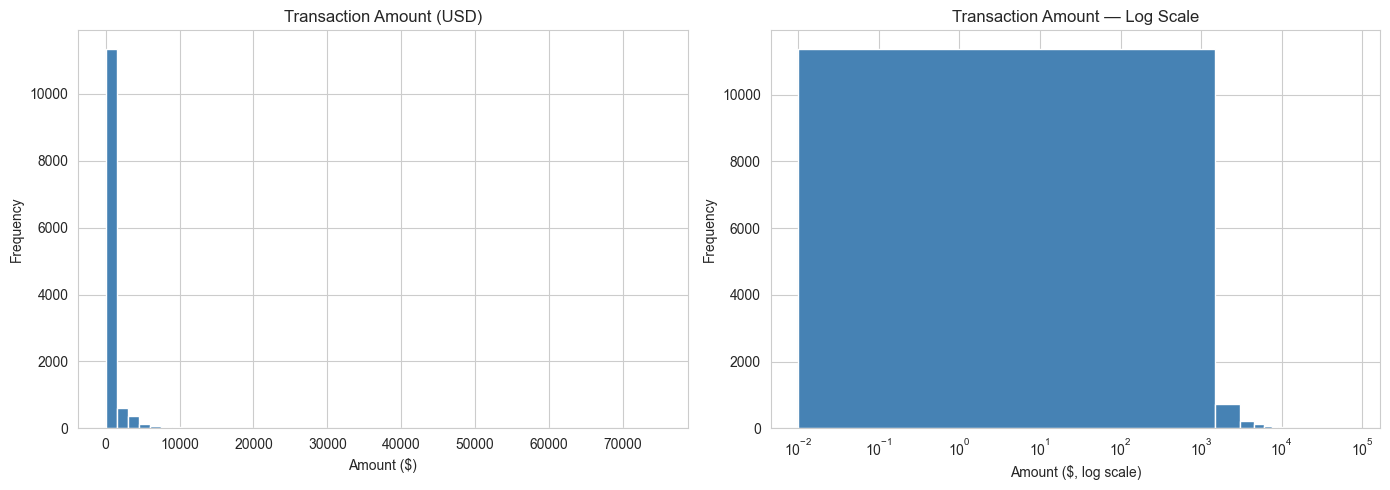

In [29]:
# 3. Amount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
amounts = df_txns["amount_cents"] / 100
axes[0].hist(amounts, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Transaction Amount (USD)")
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Frequency")
axes[1].hist(amounts[amounts > 0], bins=50, color="steelblue", edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_title("Transaction Amount — Log Scale")
axes[1].set_xlabel("Amount ($, log scale)")
axes[1].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

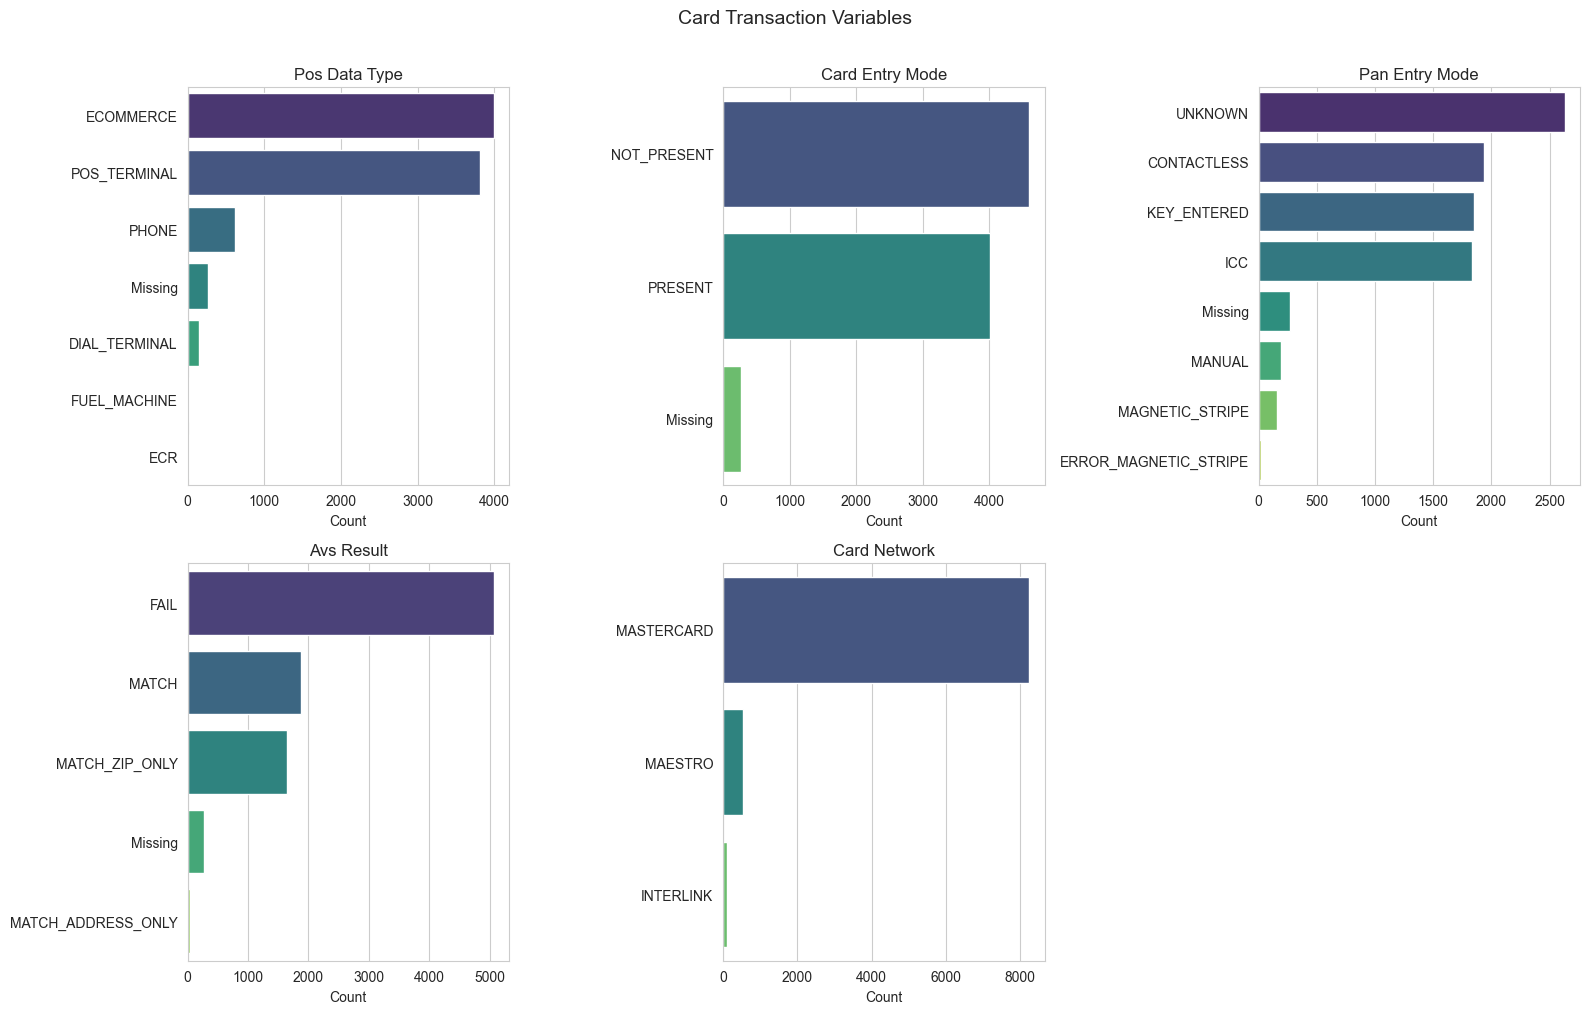

In [30]:
# 4. Card-only variables
card = df_txns[df_txns["entry_type"] == "card"].copy()
card_cols = ["pos_data_type", "card_entry_mode", "pan_entry_mode", "avs_result", "card_network"]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for ax, col in zip(axes, card_cols):
    vc = card[col].value_counts(dropna=False).head(8)
    labels = [str(x) if pd.notna(x) else "Missing" for x in vc.index]
    sns.barplot(x=vc.values, y=labels, hue=labels, palette="viridis", legend=False, ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Count")
for ax in axes[len(card_cols):]:
    ax.axis("off")
plt.suptitle("Card Transaction Variables", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

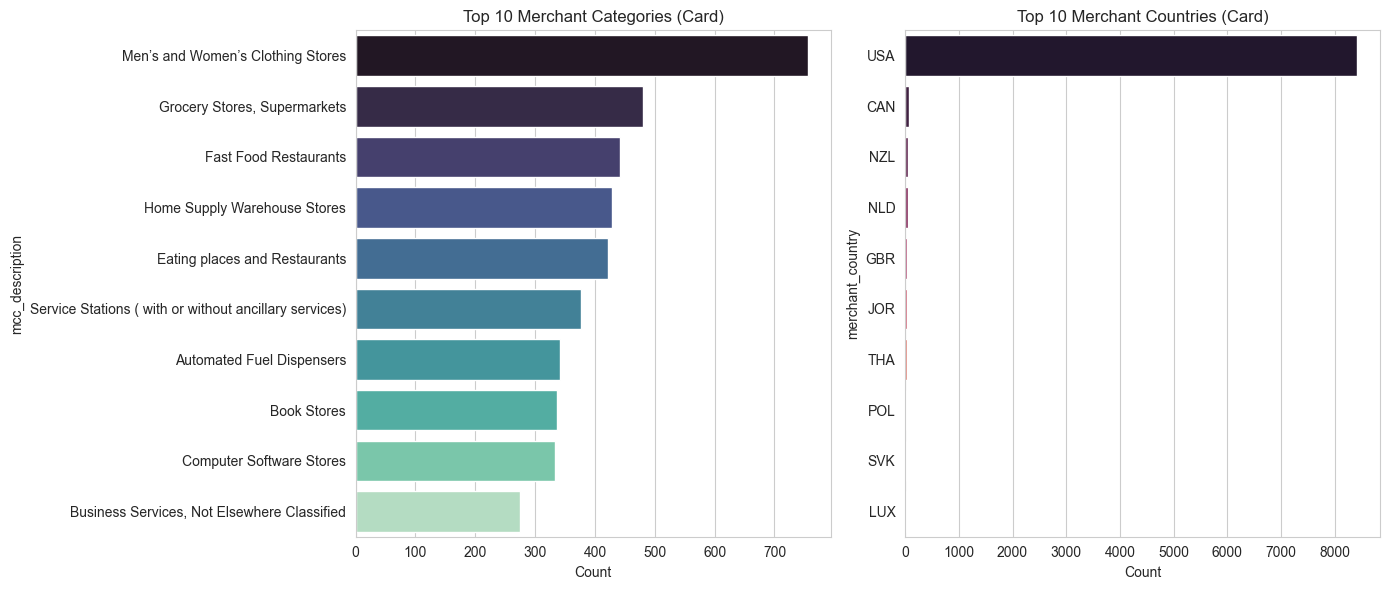

In [31]:
# 5. Top merchant categories and countries (card)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_mcc = card["mcc_description"].value_counts().head(10)
sns.barplot(x=top_mcc.values, y=top_mcc.index, hue=top_mcc.index, palette="mako", legend=False, ax=axes[0])
axes[0].set_title("Top 10 Merchant Categories (Card)")
axes[0].set_xlabel("Count")
top_country = card["merchant_country"].value_counts().head(10)
sns.barplot(x=top_country.values, y=top_country.index, hue=top_country.index, palette="rocket", legend=False, ax=axes[1])
axes[1].set_title("Top 10 Merchant Countries (Card)")
axes[1].set_xlabel("Count")
plt.tight_layout()
plt.show()

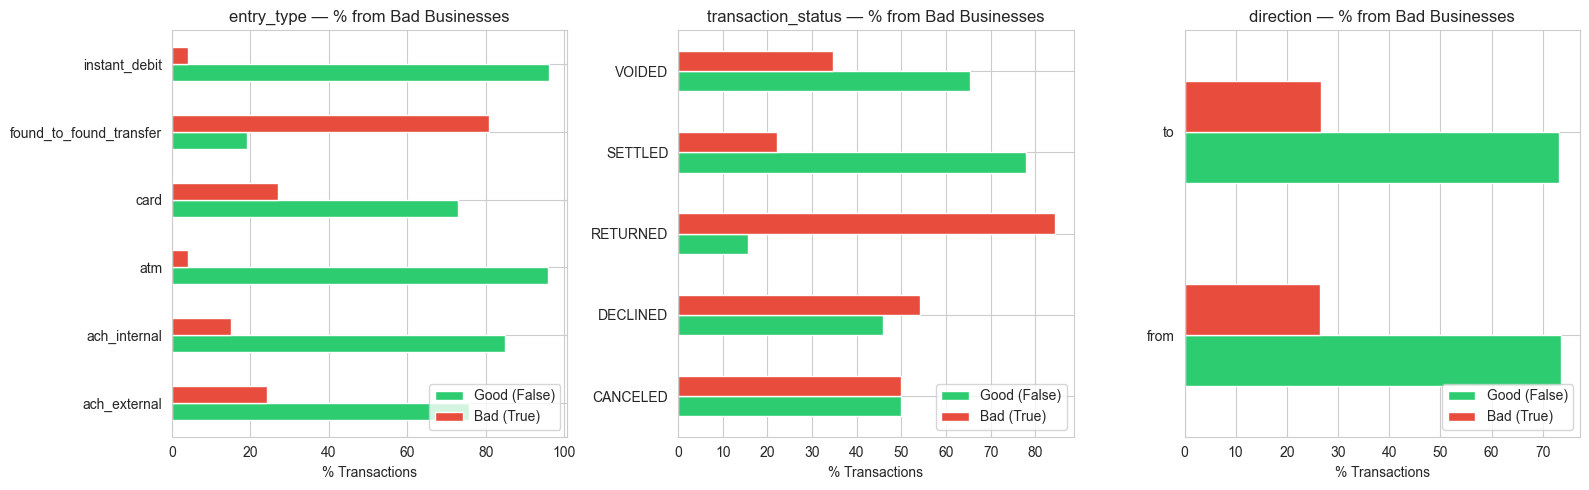

In [32]:
# 6. Categorical variables by is_bad (% from bad businesses)
compare_cols = ["entry_type", "transaction_status", "direction"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, compare_cols):
    ct = pd.crosstab(df_combined[col], df_combined["is_bad"], normalize="index") * 100
    ct.plot(kind="barh", stacked=False, ax=ax, color=["#2ecc71", "#e74c3c"])
    ax.set_title(f"{col} — % from Bad Businesses")
    ax.set_xlabel("% Transactions")
    ax.legend(["Good (False)", "Bad (True)"], loc="lower right")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

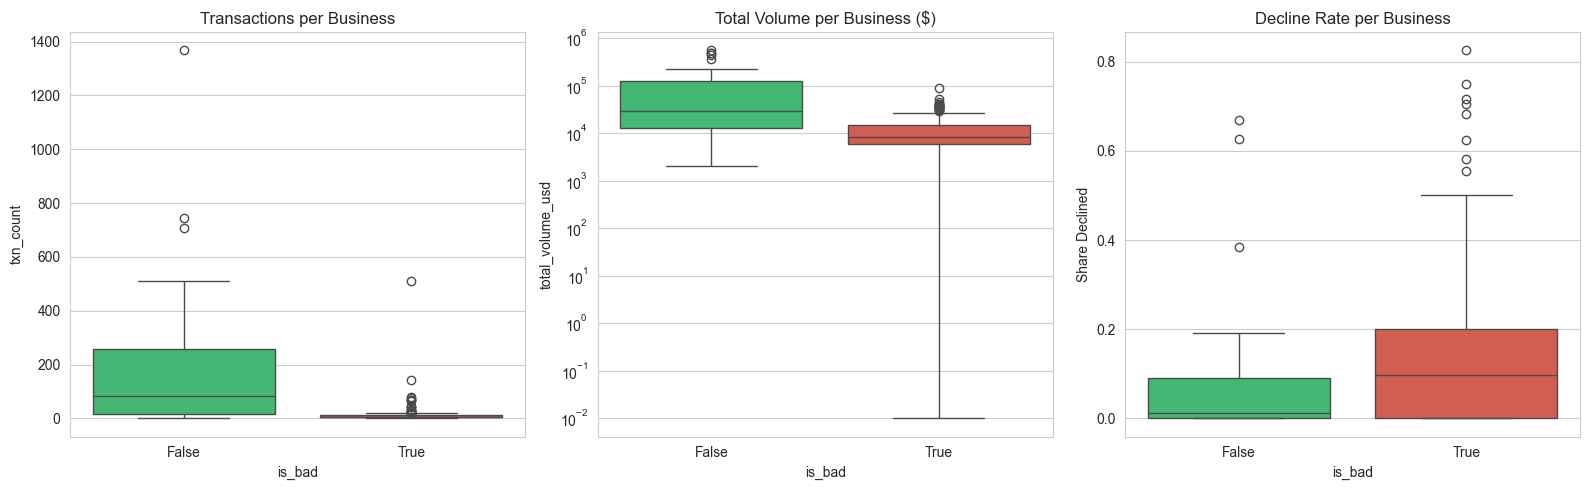

In [33]:
# 7. Business-level patterns by label
biz = df_combined.groupby(["business_token", "is_bad"]).agg(
    txn_count=("amount_cents", "size"),
    total_volume=("amount_cents", "sum"),
    decline_rate=("transaction_status", lambda s: (s == "DECLINED").mean()),
).reset_index()
biz["total_volume_usd"] = biz["total_volume"] / 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(data=biz, x="is_bad", y="txn_count", hue="is_bad", palette=["#2ecc71", "#e74c3c"], legend=False, ax=axes[0])
axes[0].set_title("Transactions per Business")
sns.boxplot(data=biz, x="is_bad", y="total_volume_usd", hue="is_bad", palette=["#2ecc71", "#e74c3c"], legend=False, ax=axes[1])
axes[1].set_title("Total Volume per Business ($)")
axes[1].set_yscale("log")
sns.boxplot(data=biz, x="is_bad", y="decline_rate", hue="is_bad", palette=["#2ecc71", "#e74c3c"], legend=False, ax=axes[2])
axes[2].set_title("Decline Rate per Business")
axes[2].set_ylabel("Share Declined")
plt.tight_layout()
plt.show()

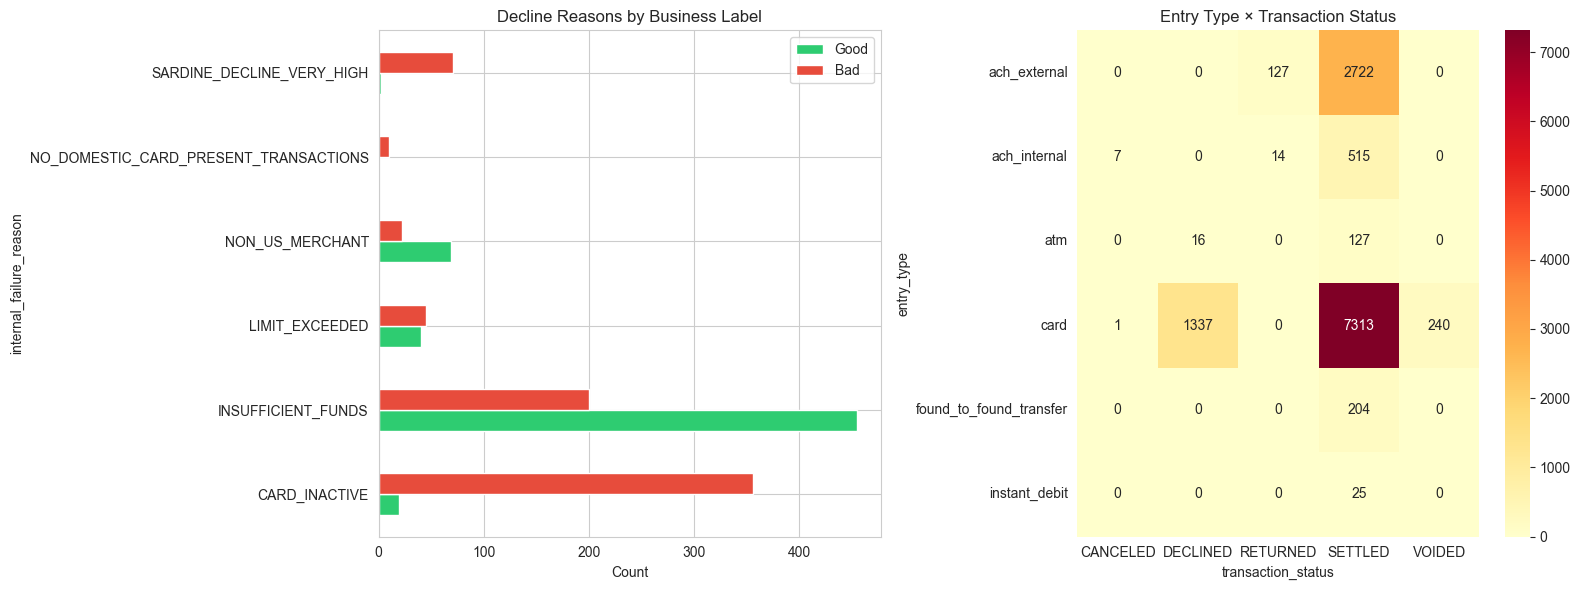

In [34]:
# 8. Decline reasons and entry type × status heatmap
declined = df_combined[df_combined["transaction_status"] == "DECLINED"]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

reason_ct = pd.crosstab(declined["internal_failure_reason"], declined["is_bad"])
reason_ct.plot(kind="barh", ax=axes[0], color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Decline Reasons by Business Label")
axes[0].set_xlabel("Count")
axes[0].legend(["Good", "Bad"])

pivot = pd.crosstab(df_combined["entry_type"], df_combined["transaction_status"])
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Entry Type × Transaction Status")
plt.tight_layout()
plt.show()

# Feature Engineering

In [35]:
cat_cols = [
    'entry_type', 'direction', 'transaction_status', 'internal_failure_reason',
    'merchant_country', 'pos_data_type', 'token_wallet_type', 'pos_data_attended',
    'pos_data_on_premise', 'card_entry_mode', 'pin_entered', 'pan_entry_mode',
    'card_network', 'avs_result',
]

def clean_val(v):
    return str(v).lower().replace(' ', '_').replace('/', '_').replace('-', '_')

df_sorted = (
    df_combined
    .sort_values(['business_token', 'transaction_date'])
    .reset_index(drop=True)
    .copy()
)
df_sorted['amount_usd'] = df_sorted['amount_cents'] / 100

# One-hot encode: cnt (1/0) and amt (amount if matches, else 0)
indicator_frames = []
for col in cat_cols:
    dummies = pd.get_dummies(df_sorted[col], dummy_na=False).astype(float)
    cnt = dummies.rename(columns=lambda v: f"{col}__{clean_val(v)}__cnt")
    amt = dummies.multiply(df_sorted['amount_usd'], axis=0).rename(columns=lambda v: f"{col}__{clean_val(v)}__amt")
    indicator_frames.extend([cnt, amt])

df_indicators = pd.concat(indicator_frames, axis=1)
indicator_cols = df_indicators.columns.tolist()

df_feat = pd.concat([df_sorted[['business_token', 'transaction_date']], df_indicators], axis=1)

# Lifetime: expanding cumsum per business (includes current transaction)
lifetime = df_feat.groupby('business_token')[indicator_cols].cumsum()
lifetime.columns = [c + '__lifetime' for c in lifetime.columns]

# Rolling windows: per business, preserving original row order
def make_rolling(df_feat, indicator_cols, window, suffix):
    parts = []
    for biz, grp in df_feat.groupby('business_token'):
        rolled = (
            grp.set_index('transaction_date')[indicator_cols]
            .rolling(window, closed='both')
            .sum()
        )
        rolled.index = grp.index
        parts.append(rolled)
    out = pd.concat(parts).sort_index()
    out.columns = [c + suffix for c in out.columns]
    return out

rolling_7d  = make_rolling(df_feat, indicator_cols, '7D',  '__7d')
rolling_14d = make_rolling(df_feat, indicator_cols, '14D', '__14d')

df_combined_features = pd.concat([df_sorted, lifetime, rolling_7d, rolling_14d], axis=1)

print("Shape:", df_combined_features.shape)  # (12658, 550)

Shape: (12648, 550)


In [36]:
df_combined_features.head()

,business_token,transaction_date,entry_type,direction,amount_cents,transaction_status,internal_failure_reason,vendor_name,mcc,mcc_description,...,card_network__maestro__amt__14d,card_network__mastercard__amt__14d,avs_result__fail__cnt__14d,avs_result__match__cnt__14d,avs_result__match_address_only__cnt__14d,avs_result__match_zip_only__cnt__14d,avs_result__fail__amt__14d,avs_result__match__amt__14d,avs_result__match_address_only__amt__14d,avs_result__match_zip_only__amt__14d
0,business_1HJSvTLCQ18n,2022-12-02 17:31:07,ach_external,to,52,SETTLED,NaN,p1ui53B2Bxs9gvPmJQfaVcpAfin+KF6I22PI+Ugh6wM=,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,business_1HJSvTLCQ18n,2022-12-02 17:31:11,ach_external,to,36,SETTLED,NaN,p1ui53B2Bxs9gvPmJQfaVcpAfin+KF6I22PI+Ugh6wM=,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,business_1HJSvTLCQ18n,2022-12-02 17:40:58,ach_external,from,52,SETTLED,NaN,p1ui53B2Bxs9gvPmJQfaVcpAfin+KF6I22PI+Ugh6wM=,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,business_1HJSvTLCQ18n,2022-12-02 17:40:59,ach_external,from,36,SETTLED,NaN,p1ui53B2Bxs9gvPmJQfaVcpAfin+KF6I22PI+Ugh6wM=,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,business_1HJSvTLCQ18n,2022-12-05 22:00:26,ach_external,to,15000,SETTLED,NaN,p1ui53B2Bxs9gvPmJQfaVcpAfin+KF6I22PI+Ugh6wM=,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Model

In [37]:
# Columns to exclude from X
remove_cols = [
    # Identifiers
    'business_token',
    'transaction_date',

    # Target
    'is_bad',

    # Raw amount (keep amount_usd as a feature)
    'amount_cents',

    # High-cardinality raw columns (not encoded)
    'vendor_name',
    'mcc',
    'mcc_description',

    # Raw categorical columns already encoded as lookback features
    'entry_type',
    'direction',
    'transaction_status',
    'internal_failure_reason',
    'merchant_country',
    'pos_data_type',
    'token_wallet_type',
    'pos_data_attended',
    'pos_data_on_premise',
    'card_entry_mode',
    'pin_entered',
    'pan_entry_mode',
    'card_network',
    'avs_result',
]

X = df_combined_features.drop(columns=remove_cols)
y = df_combined_features['is_bad']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("y bad rate:", y.mean().round(4))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)
X_valid = X_test.reindex(columns=X_train.columns)
print(X_train.shape, X_valid.shape)

X shape: (12648, 529)
y shape: (12648,)
y bad rate: 0.2646
(10118, 529) (2530, 529)


In [38]:
import numpy as np

def calc_iv(X, y, bins=10):
    records = []
    total_bad  = y.sum()
    total_good = (1 - y).sum()

    for col in X.columns:
        try:
            x = X[col].fillna(-1)
            if x.nunique() <= bins:
                cuts = pd.Categorical(x)
                grouped = pd.DataFrame({'x': cuts, 'y': y.values}).groupby('x', observed=True)['y']
            else:
                cuts = pd.qcut(x, q=bins, duplicates='drop')
                grouped = pd.DataFrame({'x': cuts, 'y': y.values}).groupby('x', observed=True)['y']

            stats = grouped.agg(['sum', 'count'])
            stats.columns = ['bad', 'total']
            stats['good']     = stats['total'] - stats['bad']
            stats['pct_bad']  = stats['bad']  / total_bad
            stats['pct_good'] = stats['good'] / total_good
            stats = stats[(stats['pct_bad'] > 0) & (stats['pct_good'] > 0)]
            stats['woe'] = np.log(stats['pct_good'] / stats['pct_bad'])
            stats['iv']  = (stats['pct_good'] - stats['pct_bad']) * stats['woe']
            iv = stats['iv'].sum()
        except Exception:
            iv = None
        records.append({'feature': col, 'iv': iv})

    iv_df = (
        pd.DataFrame(records)
        .dropna()
        .sort_values('iv', ascending=False)
        .reset_index(drop=True)
    )
    iv_df['strength'] = pd.cut(
        iv_df['iv'],
        bins=[-1, 0.02, 0.1, 0.3, 0.5, float('inf')],
        labels=['useless', 'weak', 'medium', 'strong', 'suspicious']
    )
    return iv_df

iv_df = calc_iv(X_train, y_train)
print(iv_df.head(20))
print("\nStrength breakdown:")
print(iv_df['strength'].value_counts())

                                        feature        iv    strength
0     avs_result__match_zip_only__amt__lifetime  2.664464  suspicious
1    transaction_status__settled__cnt__lifetime  2.439171  suspicious
2                  direction__to__amt__lifetime  2.187544  suspicious
3       pos_data_attended__false__cnt__lifetime  2.177525  suspicious
4       pos_data_type__ecommerce__cnt__lifetime  2.167560  suspicious
5   card_entry_mode__not_present__cnt__lifetime  2.155713  suspicious
6      pos_data_on_premise__true__cnt__lifetime  2.124288  suspicious
7          merchant_country__usa__cnt__lifetime  2.064031  suspicious
8                direction__from__cnt__lifetime  2.024823  suspicious
9              avs_result__match__cnt__lifetime  1.985107  suspicious
10       pan_entry_mode__unknown__amt__lifetime  1.974457  suspicious
11      entry_type__ach_external__amt__lifetime  1.957563  suspicious
12          pos_data_type__phone__amt__lifetime  1.927990  suspicious
13              entr

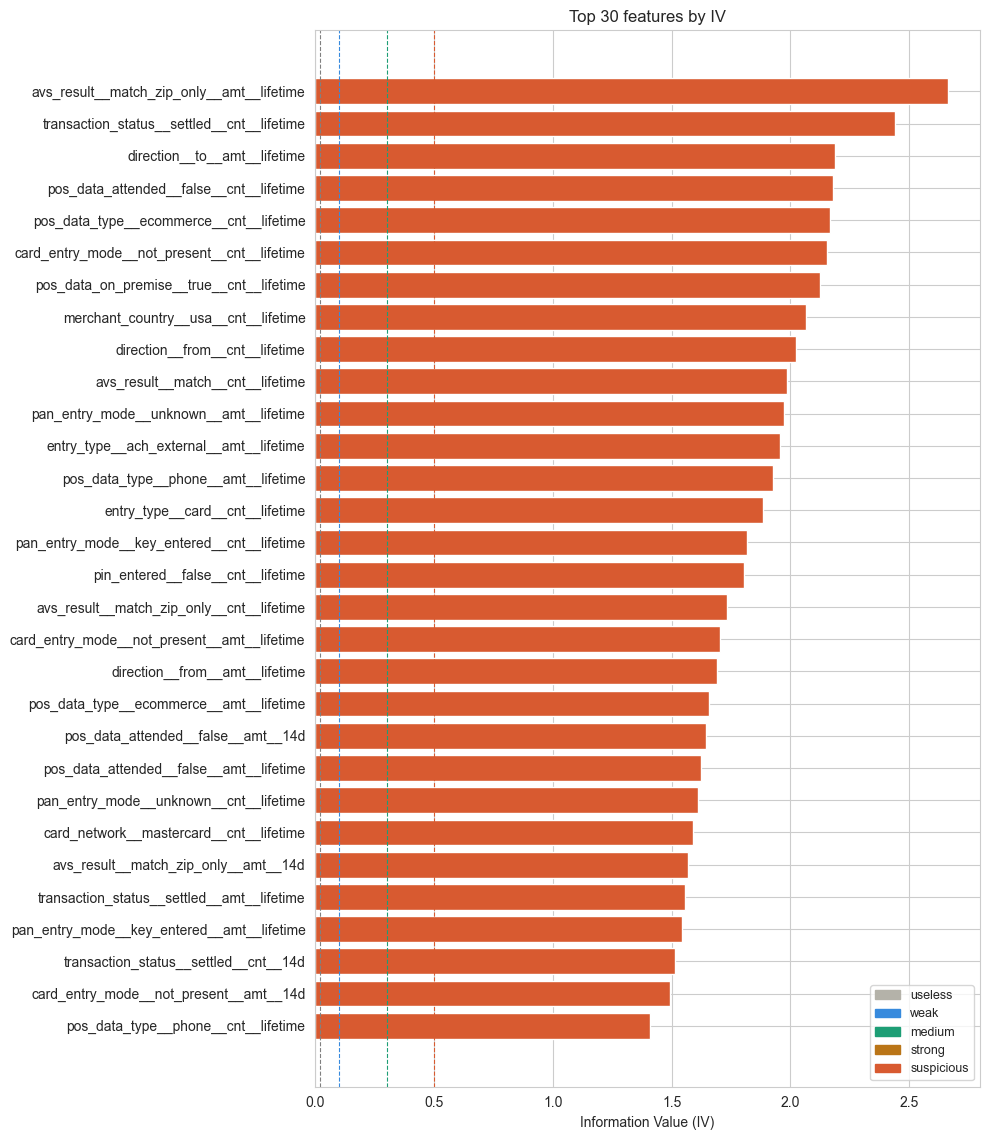

In [39]:
def plot_iv(iv_df, top_n=30):
    palette = {'useless': '#b4b2a9', 'weak': '#378ADD', 'medium': '#1D9E75', 'strong': '#BA7517', 'suspicious': '#D85A30'}

    top = iv_df.head(top_n).sort_values('iv')

    fig, ax = plt.subplots(figsize=(10, top_n * 0.35 + 1))
    bars = ax.barh(
        top['feature'],
        top['iv'],
        color=[palette[s] for s in top['strength']],
        edgecolor='white'
    )

    ax.set_xlabel('Information Value (IV)')
    ax.set_title(f'Top {top_n} features by IV')
    ax.axvline(0.02, color='grey', linestyle='--', linewidth=0.8, label='Weak (0.02)')
    ax.axvline(0.1,  color='#378ADD', linestyle='--', linewidth=0.8, label='Medium (0.1)')
    ax.axvline(0.3,  color='#1D9E75', linestyle='--', linewidth=0.8, label='Strong (0.3)')
    ax.axvline(0.5,  color='#D85A30', linestyle='--', linewidth=0.8, label='Suspicious (0.5)')

    legend_patches = [plt.Rectangle((0,0),1,1, color=c, label=l) for l, c in palette.items()]
    ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

    plt.tight_layout()
    plt.show()

plot_iv(iv_df, top_n=30)

Business-level: 323 businesses, 528 features
Bad rate: 84.2%


Features after IV filter: 251  (non-zero variance: 251)
Train: 258 businesses | Test: 65 businesses

Decision Tree results:
  Train AUC : 0.9939
  Test  AUC : 0.8855
  Test  KS  : 0.7636

              precision    recall  f1-score   support

        good       0.80      0.80      0.80        10
         bad       0.96      0.96      0.96        55

    accuracy                           0.94        65
   macro avg       0.88      0.88      0.88        65
weighted avg       0.94      0.94      0.94        65

Confusion matrix [good / bad]:
[[ 8  2]
 [ 2 53]]

Decision Tree Rules:
|--- pan_entry_mode__contactless__amt__7d <= 717.76
|   |--- direction__to__amt__7d <= 1496.00
|   |   |--- weights: [3.15, 2.97] class: False
|   |--- direction__to__amt__7d >  1496.00
|   |   |--- token_wallet_type__apple_pay__cnt__14d <= 2.50
|   |   |   |--- weights: [91.24, 0.00] class: False
|   |   |--- token_wallet_type__apple_pay__cnt__14d >  2.50
|   |   |   |--- weights: [9.44, 1.19] class: False
|-

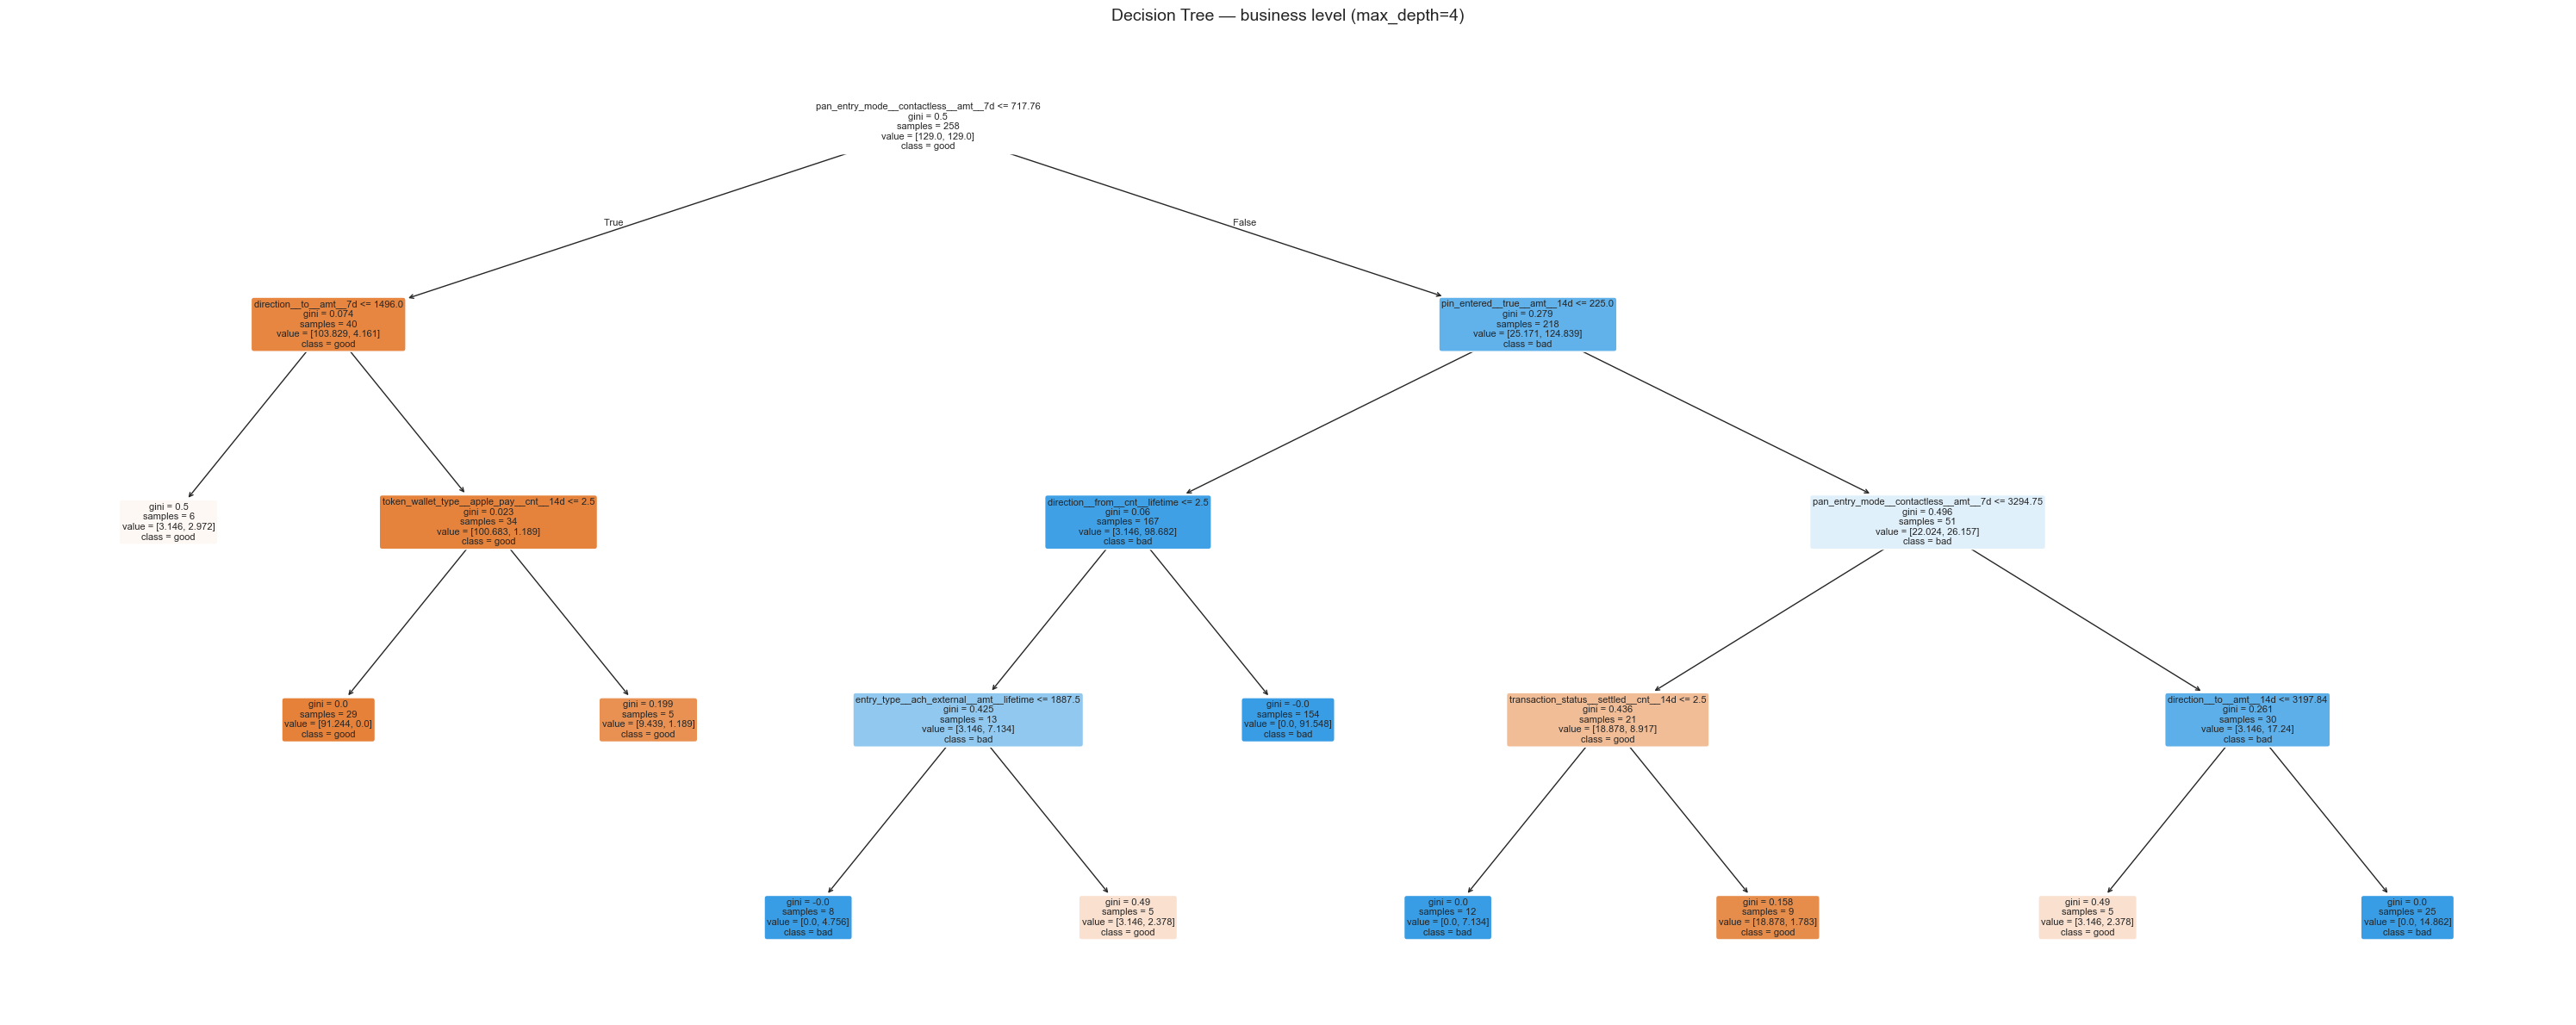

Saved: decision_tree_biz.png


In [40]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split as sk_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

# ── 1. Aggregate df_combined_features to business level ──────────────────────
biz_lifetime_cols = [c for c in df_combined_features.columns if c.endswith("__lifetime")]
biz_7d_cols       = [c for c in df_combined_features.columns if c.endswith("__7d")]
biz_14d_cols      = [c for c in df_combined_features.columns if c.endswith("__14d")]

biz_lifetime = (
    df_combined_features.sort_values("transaction_date")
    .groupby("business_token")[biz_lifetime_cols].last()
)
biz_7d  = df_combined_features.groupby("business_token")[biz_7d_cols].max()
biz_14d = df_combined_features.groupby("business_token")[biz_14d_cols].max()
biz_label = df_combined_features.groupby("business_token")["is_bad"].first()

biz_X = pd.concat([biz_lifetime, biz_7d, biz_14d], axis=1).loc[biz_label.index]
biz_y = biz_label

print(f"Business-level: {biz_X.shape[0]} businesses, {biz_X.shape[1]} features")
print(f"Bad rate: {biz_y.mean():.1%}")

# ── 2. IV filter at business level ───────────────────────────────────────────
IV_THRESHOLD = 0.02
iv_biz = calc_iv(biz_X, biz_y)
iv_biz_cols = iv_biz[iv_biz["iv"] >= IV_THRESHOLD]["feature"].tolist()
biz_model_cols = [c for c in iv_biz_cols if biz_X[c].std() > 0]
print(f"Features after IV filter: {len(iv_biz_cols)}  (non-zero variance: {len(biz_model_cols)})")

# ── 3. Train / test split ────────────────────────────────────────────────────
RANDOM_STATE = 42
X_biz_tr, X_biz_te, y_biz_tr, y_biz_te = sk_split(
    biz_X[biz_model_cols], biz_y,
    test_size=0.20, stratify=biz_y, random_state=RANDOM_STATE
)
print(f"Train: {X_biz_tr.shape[0]} businesses | Test: {X_biz_te.shape[0]} businesses")

# ── 4. Fit Decision Tree ─────────────────────────────────────────────────────
dt = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
dt.fit(X_biz_tr, y_biz_tr)

# ── 5. Metrics ───────────────────────────────────────────────────────────────
dt_prob_tr = dt.predict_proba(X_biz_tr)[:, 1]
dt_prob_te = dt.predict_proba(X_biz_te)[:, 1]
dt_pred_te = dt.predict(X_biz_te)

train_auc = roc_auc_score(y_biz_tr, dt_prob_tr)
test_auc  = roc_auc_score(y_biz_te, dt_prob_te)
ks  = ks_2samp(
    dt_prob_te[np.array(y_biz_te) == 1],
    dt_prob_te[np.array(y_biz_te) == 0]
).statistic

print(f"\nDecision Tree results:")
print(f"  Train AUC : {train_auc:.4f}")
print(f"  Test  AUC : {test_auc:.4f}")
print(f"  Test  KS  : {ks:.4f}")
print()
print(classification_report(y_biz_te, dt_pred_te, target_names=["good", "bad"]))
print("Confusion matrix [good / bad]:")
print(confusion_matrix(y_biz_te, dt_pred_te))

# ── 6. Text rules ────────────────────────────────────────────────────────────
print("\nDecision Tree Rules:")
print(export_text(dt, feature_names=biz_model_cols, max_depth=4, decimals=2, show_weights=True))

# ── 7. Visual tree ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(30, 12))
plot_tree(
    dt,
    feature_names=biz_model_cols,
    class_names=["good", "bad"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4,
    ax=ax,
    impurity=True,
    proportion=False,
)
plt.title("Decision Tree — business level (max_depth=4)", fontsize=14)
plt.tight_layout()
plt.savefig("decision_tree_biz.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: decision_tree_biz.png")


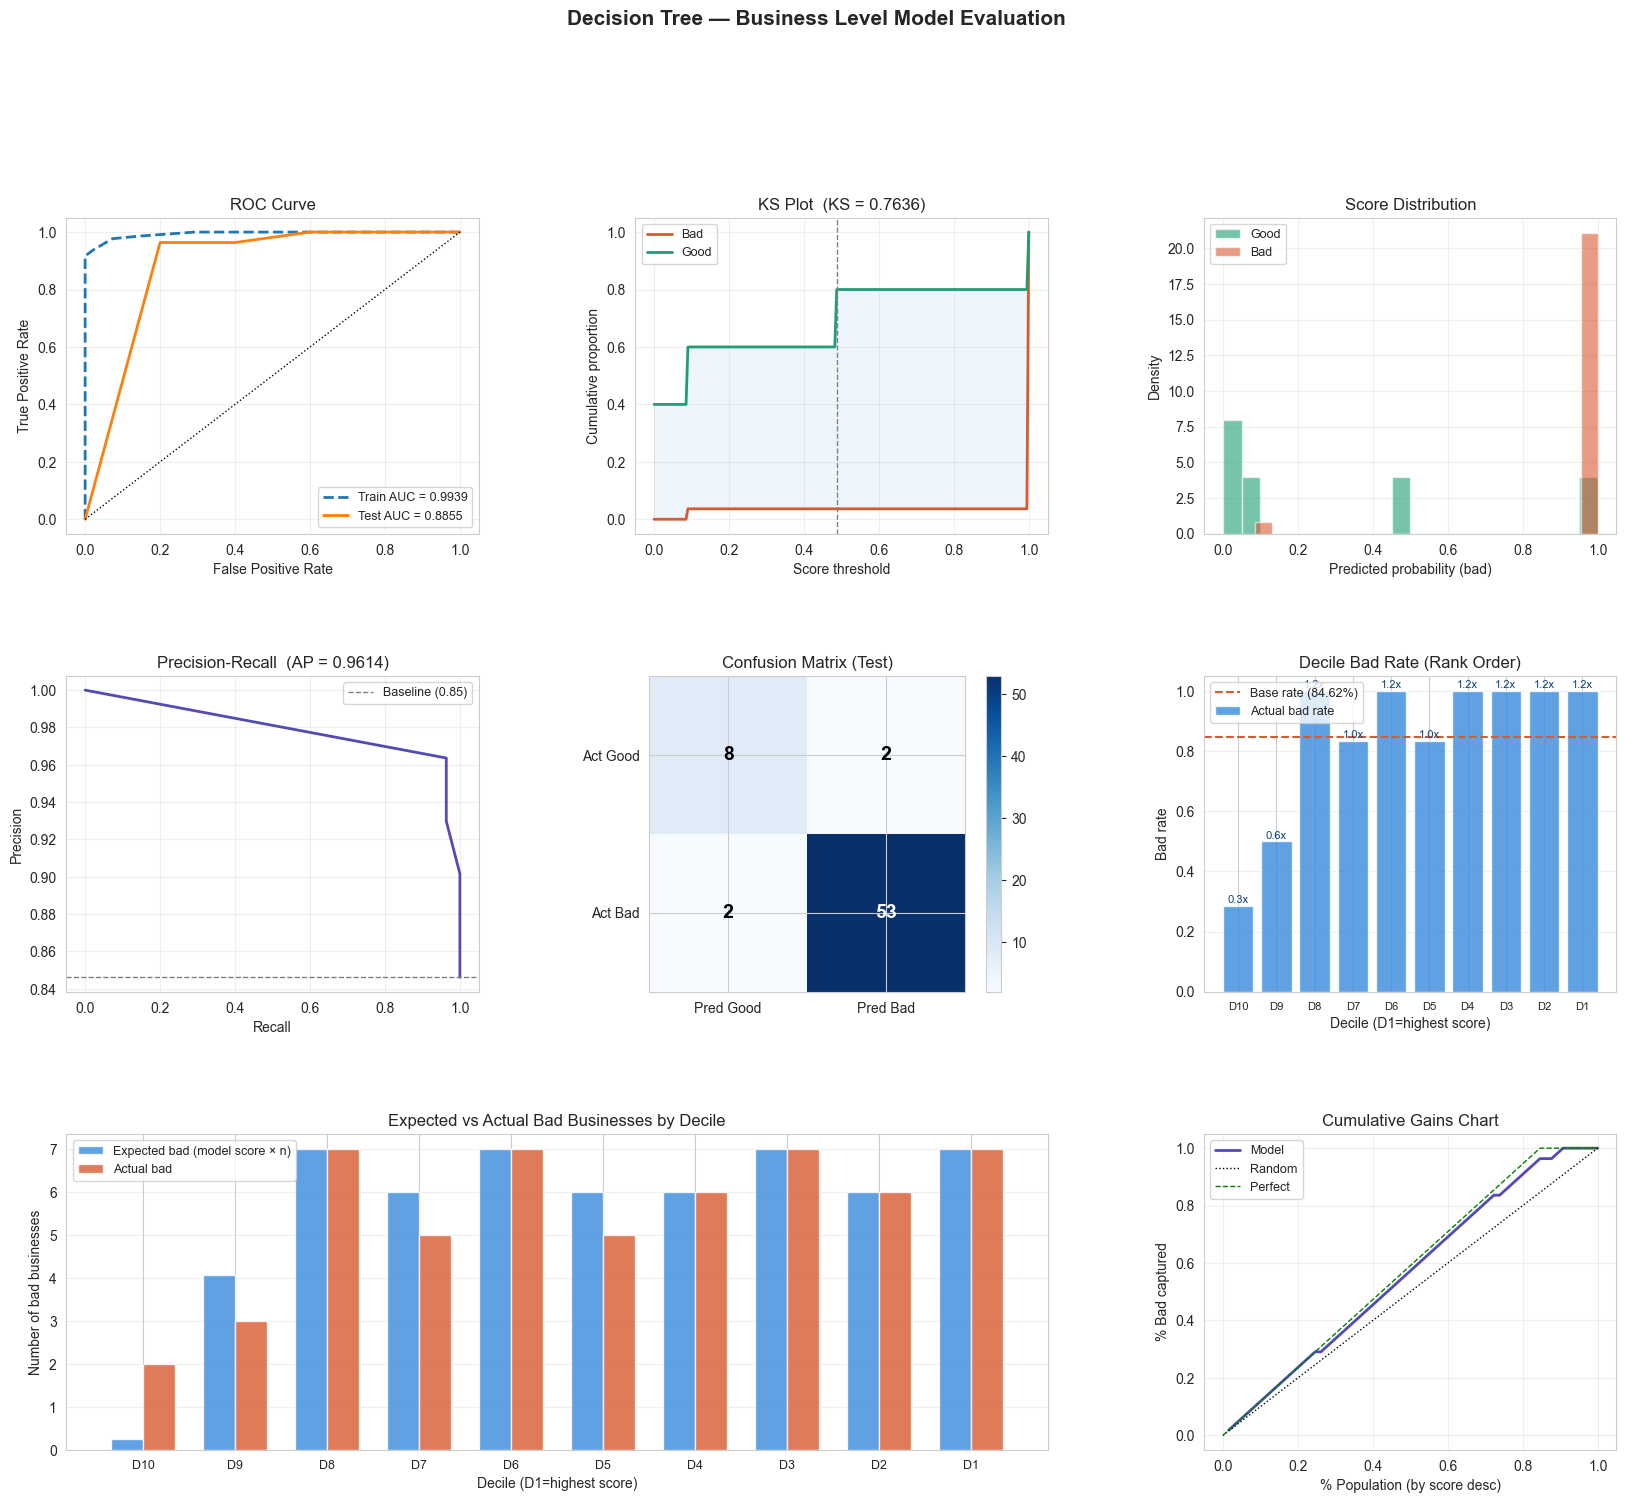

Saved: dt_evaluation.png

Decile Summary Table:
decile  n  bad_cnt  bad_rate  lift
    10  7        2     0.286 0.338
     9  6        3     0.500 0.591
     8  7        7     1.000 1.182
     7  6        5     0.833 0.985
     6  7        7     1.000 1.182
     5  6        5     0.833 0.985
     4  6        6     1.000 1.182
     3  7        7     1.000 1.182
     2  6        6     1.000 1.182
     1  7        7     1.000 1.182


In [41]:
# ── Decision Tree Model Evaluation ───────────────────────────────────────────
from sklearn.metrics import roc_curve, auc as sk_auc, confusion_matrix
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# Scores and labels (from previous cell)
prob_tr = dt.predict_proba(X_biz_tr)[:, 1]
prob_te = dt.predict_proba(X_biz_te)[:, 1]
y_tr    = np.array(y_biz_tr)
y_te    = np.array(y_biz_te)

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── 1. ROC Curve ─────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for y, p, label, ls in [(y_tr, prob_tr, "Train", "--"), (y_te, prob_te, "Test", "-")]:
    fpr, tpr, _ = roc_curve(y, p)
    auc_val = sk_auc(fpr, tpr)
    ax1.plot(fpr, tpr, ls=ls, lw=2, label=f"{label} AUC = {auc_val:.4f}")
ax1.plot([0,1],[0,1],"k:",lw=1)
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve"); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# ── 2. KS Plot ───────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
thresholds = np.linspace(0, 1, 200)
bad_te  = prob_te[y_te == 1]
good_te = prob_te[y_te == 0]
cum_bad  = [(bad_te  <= t).mean() for t in thresholds]
cum_good = [(good_te <= t).mean() for t in thresholds]
ks_stat  = ks_2samp(bad_te, good_te).statistic
ks_thresh = thresholds[np.argmax(np.abs(np.array(cum_bad) - np.array(cum_good)))]
ax2.plot(thresholds, cum_bad,  lw=2, color="#D85A30", label="Bad")
ax2.plot(thresholds, cum_good, lw=2, color="#1D9E75", label="Good")
ax2.axvline(ks_thresh, color="gray", ls="--", lw=1)
ax2.fill_between(thresholds, cum_bad, cum_good, alpha=0.08, color="#378ADD")
ax2.set_xlabel("Score threshold"); ax2.set_ylabel("Cumulative proportion")
ax2.set_title(f"KS Plot  (KS = {ks_stat:.4f})"); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# ── 3. Score Distribution ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(good_te, bins=20, alpha=0.6, color="#1D9E75", label="Good", density=True)
ax3.hist(bad_te,  bins=20, alpha=0.6, color="#D85A30", label="Bad",  density=True)
ax3.set_xlabel("Predicted probability (bad)"); ax3.set_ylabel("Density")
ax3.set_title("Score Distribution"); ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

# ── 4. Precision-Recall Curve ────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score
ax4 = fig.add_subplot(gs[1, 0])
prec, rec, _ = precision_recall_curve(y_te, prob_te)
ap = average_precision_score(y_te, prob_te)
ax4.plot(rec, prec, lw=2, color="#534AB7")
ax4.axhline(y_te.mean(), color="gray", ls="--", lw=1, label=f"Baseline ({y_te.mean():.2f})")
ax4.set_xlabel("Recall"); ax4.set_ylabel("Precision")
ax4.set_title(f"Precision-Recall  (AP = {ap:.4f})"); ax4.legend(fontsize=9); ax4.grid(alpha=0.3)

# ── 5. Confusion Matrix ──────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
cm = confusion_matrix(y_te, dt.predict(X_biz_te))
im = ax5.imshow(cm, interpolation="nearest", cmap="Blues")
ax5.set_xticks([0,1]); ax5.set_yticks([0,1])
ax5.set_xticklabels(["Pred Good","Pred Bad"]); ax5.set_yticklabels(["Act Good","Act Bad"])
for row in range(2):
    for col in range(2):
        ax5.text(col, row, cm[row, col], ha="center", va="center",
                 color="white" if cm[row, col] > cm.max()/2 else "black", fontsize=14, fontweight="bold")
ax5.set_title("Confusion Matrix (Test)"); plt.colorbar(im, ax=ax5)

# ── 6. Decile Lift Table (rank order) ───────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
df_te = pd.DataFrame({"score": prob_te, "bad": y_te})
df_te["decile"] = pd.qcut(df_te["score"].rank(method="first"), 10, labels=range(10,0,-1))
decile_tbl = (
    df_te.groupby("decile", observed=True)
    .agg(n=("bad","count"), bad_cnt=("bad","sum"))
    .assign(bad_rate=lambda d: d["bad_cnt"]/d["n"])
    .reset_index()
)
base_rate = y_te.mean()
decile_tbl["lift"] = decile_tbl["bad_rate"] / base_rate
x = np.arange(len(decile_tbl))
bars = ax6.bar(x, decile_tbl["bad_rate"], color="#378ADD", alpha=0.8, label="Actual bad rate")
ax6.axhline(base_rate, color="#D85A30", ls="--", lw=1.5, label=f"Base rate ({base_rate:.2%})")
ax6.set_xticks(x); ax6.set_xticklabels([f"D{d}" for d in decile_tbl["decile"]], fontsize=8)
ax6.set_xlabel("Decile (D1=highest score)"); ax6.set_ylabel("Bad rate")
ax6.set_title("Decile Bad Rate (Rank Order)"); ax6.legend(fontsize=9); ax6.grid(alpha=0.3, axis="y")
for bar, lift in zip(bars, decile_tbl["lift"]):
    if lift > 0:
        ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f"{lift:.1f}x", ha="center", fontsize=8, color="#0C447C")

# ── 7. Expected vs Actual by Decile ─────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0:2])
decile_tbl2 = (
    df_te.groupby("decile", observed=True)
    .agg(n=("bad","count"), actual_bad=("bad","sum"), mean_score=("score","mean"))
    .assign(expected_bad=lambda d: d["mean_score"]*d["n"])
    .reset_index()
)
x2 = np.arange(len(decile_tbl2))
w  = 0.35
ax7.bar(x2 - w/2, decile_tbl2["expected_bad"], w, color="#378ADD", alpha=0.8, label="Expected bad (model score × n)")
ax7.bar(x2 + w/2, decile_tbl2["actual_bad"],   w, color="#D85A30", alpha=0.8, label="Actual bad")
ax7.set_xticks(x2); ax7.set_xticklabels([f"D{d}" for d in decile_tbl2["decile"]], fontsize=9)
ax7.set_xlabel("Decile (D1=highest score)"); ax7.set_ylabel("Number of bad businesses")
ax7.set_title("Expected vs Actual Bad Businesses by Decile"); ax7.legend(fontsize=9); ax7.grid(alpha=0.3, axis="y")

# ── 8. Cumulative Lift / Gains Chart ─────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
df_sorted = df_te.sort_values("score", ascending=False).reset_index(drop=True)
total_bad  = y_te.sum()
cum_captured = df_sorted["bad"].cumsum() / total_bad
pct_pop = (np.arange(1, len(df_sorted)+1)) / len(df_sorted)
ax8.plot(pct_pop, cum_captured, lw=2, color="#534AB7", label="Model")
ax8.plot([0,1],[0,1], "k:", lw=1, label="Random")
ax8.plot([0, total_bad/len(df_sorted), 1],[0,1,1],"g--",lw=1,label="Perfect")
ax8.set_xlabel("% Population (by score desc)"); ax8.set_ylabel("% Bad captured")
ax8.set_title("Cumulative Gains Chart"); ax8.legend(fontsize=9); ax8.grid(alpha=0.3)

plt.suptitle("Decision Tree — Business Level Model Evaluation", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("dt_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: dt_evaluation.png")

# Print summary table
print("\nDecile Summary Table:")
print(decile_tbl[["decile","n","bad_cnt","bad_rate","lift"]].to_string(index=False, float_format="{:.3f}".format))


# Rule Recommendations

Operational rules derived from business-level transaction patterns. See `Risk_Brief.md` for the 1-page summary.

In [42]:
def build_business_rule_features(df_combined: pd.DataFrame) -> pd.DataFrame:
    """Aggregate transaction history to business-level rule inputs."""
    rows = []
    for token, g in df_combined.groupby("business_token"):
        start = g["transaction_date"].min()
        end = g["transaction_date"].max()
        span_days = (end - start).days + 1
        early7 = g[g["transaction_date"] <= start + pd.Timedelta(days=6)]
        total_amt = g["amount_cents"].sum()
        atm_amt = g.loc[g["entry_type"] == "atm", "amount_cents"].sum()
        card = g[g["entry_type"] == "card"]
        cnp = card[card["card_entry_mode"] == "NOT_PRESENT"]
        avs_fail = card[card["avs_result"].isin(["FAIL", "NO_MATCH", "NOT_VERIFIED"])]
        ach_out_7d = early7.loc[
            (early7["entry_type"] == "ach_external") & (early7["direction"] == "to"),
            "amount_cents",
        ].sum()
        rows.append({
            "business_token": token,
            "is_bad": g["is_bad"].iloc[0],
            "span_days": span_days,
            "decline_rate": (g["transaction_status"] == "DECLINED").mean(),
            "atm_share": atm_amt / total_amt if total_amt else 0,
            "cnp_share": len(cnp) / len(card) if len(card) else 0,
            "avs_fail_rate": len(avs_fail) / len(card) if len(card) else 0,
            "ach_out_7d": ach_out_7d,
        })
    return pd.DataFrame(rows)


biz_agg = build_business_rule_features(df_combined)

rule1 = biz_agg["atm_share"] >= 0.10
rule2 = (biz_agg["span_days"] <= 7) & (biz_agg["decline_rate"] >= 0.05)
rule3 = (biz_agg["cnp_share"] >= 0.50) & (biz_agg["avs_fail_rate"] >= 0.30)
rule4 = (biz_agg["span_days"] <= 14) & (biz_agg["ach_out_7d"] >= 100_000)
combined_recommended = rule2 | rule4

biz_agg["flag_rule1"] = rule1
biz_agg["flag_rule2"] = rule2
biz_agg["flag_rule3"] = rule3
biz_agg["flag_rule4"] = rule4
biz_agg["flag_combined"] = combined_recommended
biz_agg.head()

,business_token,is_bad,span_days,decline_rate,atm_share,cnp_share,avs_fail_rate,ach_out_7d,flag_rule1,flag_rule2,flag_rule3,flag_rule4,flag_combined
0,business_1HJSvTLCQ18n,True,6,0.1,0.0,0.000000,1.000000,400088,False,True,False,True,True
1,business_1PLuhtCAGwnx,True,43,0.1,0.0,0.416667,0.916667,338161,False,False,False,False,False
2,business_1YM9RcwccuTN,True,15,0.0,0.0,0.000000,1.000000,0,False,False,False,False,False
3,business_1YTWYP1f1Nt4,False,8,0.0,0.0,0.000000,1.000000,230802,False,False,False,True,True
4,business_1b3j4Fqi12Zf,True,2,0.0,0.0,0.000000,1.000000,200115,False,False,False,True,True


In [43]:
def rule_metrics(mask: pd.Series, label: pd.Series) -> pd.Series:
    bad = label.astype(bool)
    tp = int((mask & bad).sum())
    fp = int((mask & ~bad).sum())
    fn = int((~mask & bad).sum())
    tn = int((~mask & ~bad).sum())
    precision = tp / (tp + fp) if tp + fp else 0
    recall = tp / (tp + fn) if tp + fn else 0
    fpr = fp / (fp + tn) if fp + tn else 0
    return pd.Series({
        "flagged": int(mask.sum()),
        "true_positives": tp,
        "false_positives": fp,
        "precision": precision,
        "recall": recall,
        "false_positive_rate": fpr,
    })


rule_rows = []
for name, mask in [
    ("Rule 1: ATM >= 10% of spend", rule1),
    ("Rule 2: span <= 7d AND decline >= 5%", rule2),
    ("Rule 3: CNP >= 50% AND AVS fail >= 30%", rule3),
    ("Rule 4: span <= 14d AND ACH out >= $1k (7d)", rule4),
    ("Combined recommended (Rule 2 OR Rule 4)", combined_recommended),
]:
    row = rule_metrics(mask, biz_agg["is_bad"])
    row["rule"] = name
    rule_rows.append(row)

rule_effectiveness = pd.DataFrame(rule_rows).set_index("rule")
rule_effectiveness.to_csv("rule_effectiveness.csv")
rule_effectiveness.style.format({
    "precision": "{:.1%}",
    "recall": "{:.1%}",
    "false_positive_rate": "{:.1%}",
})

,flagged,true_positives,false_positives,precision,recall,false_positive_rate
rule,,,,,,
Rule 1: ATM >= 10% of spend,1.000000,1.000000,0.000000,100.0%,0.4%,0.0%
Rule 2: span <= 7d AND decline >= 5%,88.000000,88.000000,0.000000,100.0%,32.4%,0.0%
Rule 3: CNP >= 50% AND AVS fail >= 30%,35.000000,18.000000,17.000000,51.4%,6.6%,33.3%
Rule 4: span <= 14d AND ACH out >= $1k (7d),152.000000,146.000000,6.000000,96.1%,53.7%,11.8%
Combined recommended (Rule 2 OR Rule 4),170.000000,164.000000,6.000000,96.5%,60.3%,11.8%


Bad caught by Rule 2 only: 18
Bad caught by Rule 4 only: 76
Bad caught by both rules:  70
Bad missed by both rules:  108
Total bad in sample:       272


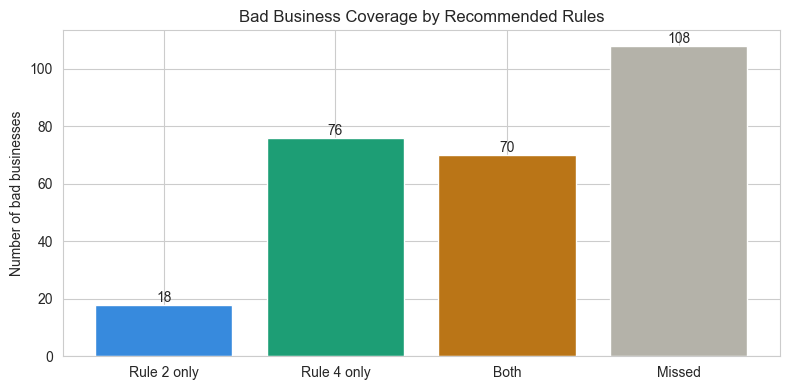

In [44]:
# Overlap of flagged bad businesses across rules (no external venn dependency)
bad_tokens = set(biz_agg.loc[biz_agg["is_bad"], "business_token"])

def flagged_bad(mask):
    return set(biz_agg.loc[mask & biz_agg["is_bad"], "business_token"])

sets = {
    "Rule 2 (declines)": flagged_bad(rule2),
    "Rule 4 (ACH cash-out)": flagged_bad(rule4),
}

only_r2 = sets["Rule 2 (declines)"] - sets["Rule 4 (ACH cash-out)"]
only_r4 = sets["Rule 4 (ACH cash-out)"] - sets["Rule 2 (declines)"]
both = sets["Rule 2 (declines)"] & sets["Rule 4 (ACH cash-out)"]
missed = bad_tokens - sets["Rule 2 (declines)"] - sets["Rule 4 (ACH cash-out)"]

print(f"Bad caught by Rule 2 only: {len(only_r2)}")
print(f"Bad caught by Rule 4 only: {len(only_r4)}")
print(f"Bad caught by both rules:  {len(both)}")
print(f"Bad missed by both rules:  {len(missed)}")
print(f"Total bad in sample:       {len(bad_tokens)}")

fig, ax = plt.subplots(figsize=(8, 4))
labels = ["Rule 2 only", "Rule 4 only", "Both", "Missed"]
counts = [len(only_r2), len(only_r4), len(both), len(missed)]
colors = ["#378ADD", "#1D9E75", "#BA7517", "#b4b2a9"]
ax.bar(labels, counts, color=colors)
ax.set_title("Bad Business Coverage by Recommended Rules")
ax.set_ylabel("Number of bad businesses")
for i, v in enumerate(counts):
    ax.text(i, v + 1, str(v), ha="center")
plt.tight_layout()
plt.show()

## Business-Level Lifetime Feature Flat File

One row per business with lifetime count/ever features for all categorical transaction fields, top merchant names, and `is_bad`.

In [45]:
from build_business_features import (
    build_business_feature_table,
    analyze_feature_bad_rates,
    evaluate_manual_rules,
)

business_features = build_business_feature_table()
business_features.to_csv("business_features_lifetime.csv", index=False)
print(business_features.shape)
business_features.filter(regex="transaction_status|top_merchant|n_transactions|span_days").head()

(328, 686)


,n_transactions,span_days,transaction_status__canceled__count,transaction_status__declined__count,transaction_status__returned__count,transaction_status__settled__count,transaction_status__voided__count,transaction_status__canceled__ever,transaction_status__declined__ever,transaction_status__returned__ever,...,top_merchant_1_name,top_merchant_1_count,top_merchant_2_name,top_merchant_2_count,top_merchant_3_name,top_merchant_3_count,top_merchant_4_name,top_merchant_4_count,top_merchant_5_name,top_merchant_5_count
0,13.0,209.0,0.0,5.0,0.0,8.0,0.0,0.0,1.0,0.0,...,Borrowlenses,3.0,"Peerspace, Inc",1.0,NaN,0.0,NaN,0.0,NaN,0.0
1,139.0,183.0,0.0,87.0,0.0,52.0,0.0,0.0,1.0,0.0,...,Trthfdr,35.0,Zoosk 1-888-939,33.0,Doordash,4.0,Microsoft,3.0,Starbucks Store,3.0
2,4.0,2.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,Coach Inc,1.0,Michael Kors,1.0,NaN,0.0,NaN,0.0,NaN,0.0
3,186.0,214.0,0.0,24.0,0.0,150.0,12.0,0.0,1.0,0.0,...,Cash App,39.0,Amzn Mktp Us,22.0,Uber Eats,15.0,Uber,11.0,Nayax Vending 46,6.0
4,4.0,30.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0


In [46]:
feature_rules = analyze_feature_bad_rates(business_features, min_support=10)
manual_rules = evaluate_manual_rules(business_features)

feature_rules.to_csv("feature_bad_rate_rules.csv", index=False)
manual_rules.to_csv("manual_rule_bad_rates.csv", index=False)

display(feature_rules.head(20))
display(manual_rules)

,rule,feature,threshold,support,bad_count,good_count,bad_rate,baseline_bad_rate,bad_rate_lift,precision,recall
0,merchant_brand__lululemon__count > 4,merchant_brand__lululemon__count,4,33,33,0,1.000000,0.841463,0.158537,1.000000,0.119565
1,merchant_country__tha__count > 0,merchant_country__tha__count,0,13,13,0,1.000000,0.841463,0.158537,1.000000,0.047101
2,merchant_country__tha__ever > 0,merchant_country__tha__ever,0,13,13,0,1.000000,0.841463,0.158537,1.000000,0.047101
3,mcc_description__women_s_accessory_and_special...,mcc_description__women_s_accessory_and_special...,2,12,12,0,1.000000,0.841463,0.158537,1.000000,0.043478
4,merchant_brand__lululemon__count > 6,merchant_brand__lululemon__count,6,12,12,0,1.000000,0.841463,0.158537,1.000000,0.043478
5,merchant_brand__coach__count > 2,merchant_brand__coach__count,2,11,11,0,1.000000,0.841463,0.158537,1.000000,0.039855
6,merchant_brand__lululemon__count > 0,merchant_brand__lululemon__count,0,167,166,1,0.994012,0.841463,0.152549,0.994012,0.601449
7,merchant_brand__lululemon__ever > 0,merchant_brand__lululemon__ever,0,167,166,1,0.994012,0.841463,0.152549,0.994012,0.601449
8,internal_failure_reason__sardine_decline_very_...,internal_failure_reason__sardine_decline_very_...,0,71,70,1,0.985915,0.841463,0.144452,0.985915,0.253623
9,internal_failure_reason__sardine_decline_very_...,internal_failure_reason__sardine_decline_very_...,0,71,70,1,0.985915,0.841463,0.144452,0.985915,0.253623


,rule,support,bad_count,good_count,bad_rate,baseline_bad_rate,bad_rate_lift,precision,recall,flagged_outgoing_usd,bad_outgoing_usd,bad_dollar_capture,severity
0,R1: span<=7d AND declined>=1,88,88,0,1.000000,0.841463,0.158537,1.000000,0.318841,0,0,0,0.0
1,R3: womens_accessory mcc count>=2,20,20,0,1.000000,0.841463,0.158537,1.000000,0.072464,0,0,0,0.0
2,R4: mens_womens_clothing mcc count>=3,151,144,7,0.953642,0.841463,0.112179,0.953642,0.521739,0,0,0,0.0
3,R5: lululemon brand count>=4,88,88,0,1.000000,0.841463,0.158537,1.000000,0.318841,0,0,0,0.0
4,R6: coach>=1 OR michael_kors>=1,31,30,1,0.967742,0.841463,0.126279,0.967742,0.108696,0,0,0,0.0
5,R8: sardine_decline_very_high ever,71,70,1,0.985915,0.841463,0.144452,0.985915,0.253623,0,0,0,0.0
6,R9: no_domestic_card_present ever,6,6,0,1.000000,0.841463,0.158537,1.000000,0.021739,0,0,0,0.0
7,TIER1: R1 OR R2,88,88,0,1.000000,0.841463,0.158537,1.000000,0.318841,0,0,0,0.0
8,TIER2: R1 OR R2 OR R3 OR R4 OR R5,202,195,7,0.965347,0.841463,0.123883,0.965347,0.706522,0,0,0,0.0
9,TIER3: TIER2 OR R7 OR R8 OR R9,213,205,8,0.962441,0.841463,0.120978,0.962441,0.742754,0,0,0,0.0


In [47]:
# %run eda_severity_analysis.py  # skipped — results shown in business flat file cells below


# Business-Level Flat File (Full Build)

One row per business:
- **Categorical counts** (`{col}__{val}_cnt`) and **ever-seen binaries** (`{col}__{val}_ever`)
- **Numeric summaries** (transaction count, amounts, life span, per entry-type totals)
- **Readable merchant name counts** (top 5 vendors, hashed names excluded)
- `is_bad` label


In [48]:
import re

CAT_COLS = [
    "entry_type", "direction", "transaction_status", "internal_failure_reason",
    "merchant_country", "pos_data_type", "token_wallet_type",
    "pos_data_attended", "pos_data_on_premise", "card_entry_mode",
    "pin_entered", "pan_entry_mode", "card_network", "avs_result",
]

def safe_col(col, val):
    v = str(val).lower().strip()
    v = re.sub(r"[^a-z0-9]+", "_", v).strip("_")
    return f"{col}__{v}"

count_frames = []
ever_frames  = []

for col in CAT_COLS:
    dummies = pd.get_dummies(df_combined[col], prefix=col, prefix_sep="__", dummy_na=False)
    # make column names safe
    dummies.columns = [
        safe_col(*c.split("__", 1)) if "__" in c else c
        for c in dummies.columns
    ]
    tmp = pd.concat([df_combined[["business_token"]], dummies], axis=1)

    cnt  = tmp.groupby("business_token").sum().astype(int)
    cnt.columns  = [c + "_cnt"  for c in cnt.columns]

    ever = cnt.clip(upper=1)
    ever.columns = [c.replace("_cnt", "_ever") for c in cnt.columns]

    count_frames.append(cnt)
    ever_frames.append(ever)

df_cat_counts = pd.concat(count_frames, axis=1)
df_cat_ever   = pd.concat(ever_frames,  axis=1)

print("Categorical count columns:", df_cat_counts.shape[1])
print("Categorical ever  columns:", df_cat_ever.shape[1])
df_cat_counts.head(3)


Categorical count columns: 88
Categorical ever  columns: 88


,entry_type__ach_external_cnt,entry_type__ach_internal_cnt,entry_type__atm_cnt,entry_type__card_cnt,entry_type__found_to_found_transfer_cnt,entry_type__instant_debit_cnt,direction__from_cnt,direction__to_cnt,transaction_status__canceled_cnt,transaction_status__declined_cnt,...,pan_entry_mode__magnetic_stripe_cnt,pan_entry_mode__manual_cnt,pan_entry_mode__unknown_cnt,card_network__interlink_cnt,card_network__maestro_cnt,card_network__mastercard_cnt,avs_result__fail_cnt,avs_result__match_cnt,avs_result__match_address_only_cnt,avs_result__match_zip_only_cnt
business_token,,,,,,,,,,,,,,,,,,,,,
business_1HJSvTLCQ18n,7,0,0,3,0,0,5,5,0,1,...,0,0,0,0,0,3,3,0,0,0
business_1PLuhtCAGwnx,14,2,0,12,2,0,19,11,0,3,...,0,0,3,0,0,12,11,1,0,0
business_1YM9RcwccuTN,2,0,0,4,3,0,7,2,0,0,...,0,0,0,0,0,4,4,0,0,0


In [49]:
df_combined["transaction_date"] = pd.to_datetime(df_combined["transaction_date"])

def numeric_features(g):
    span = (g["transaction_date"].max() - g["transaction_date"].min()).days
    card     = g[g["entry_type"] == "card"]
    atm      = g[g["entry_type"] == "atm"]
    ach_out  = g[(g["entry_type"] == "ach_external") & (g["direction"] == "to")]
    ach_in   = g[(g["entry_type"] == "ach_external") & (g["direction"] == "from")]
    inst_deb = g[g["entry_type"] == "instant_debit"]
    return pd.Series({
        "n_transactions":          len(g),
        "span_days":               span,
        "total_amount_usd":        g["amount_cents"].sum() / 100,
        "avg_amount_usd":          g["amount_cents"].mean() / 100,
        "median_amount_usd":       g["amount_cents"].median() / 100,
        "max_amount_usd":          g["amount_cents"].max() / 100,
        "n_card_txns":             len(card),
        "n_atm_txns":              len(atm),
        "n_ach_out_txns":          len(ach_out),
        "n_ach_in_txns":           len(ach_in),
        "n_instant_debit_txns":    len(inst_deb),
        "card_total_usd":          card["amount_cents"].sum() / 100,
        "atm_total_usd":           atm["amount_cents"].sum() / 100,
        "ach_out_total_usd":       ach_out["amount_cents"].sum() / 100,
        "ach_in_total_usd":        ach_in["amount_cents"].sum() / 100,
        "instant_debit_total_usd": inst_deb["amount_cents"].sum() / 100,
        "n_unique_vendors":        g["vendor_name"].nunique(),
        "n_unique_mcc":            g["mcc"].nunique(),
    })

df_numeric = df_combined.groupby("business_token").apply(numeric_features).reset_index()
print("Numeric feature columns:", df_numeric.shape[1])
df_numeric.head(3)


Numeric feature columns: 19


,business_token,n_transactions,span_days,total_amount_usd,avg_amount_usd,median_amount_usd,max_amount_usd,n_card_txns,n_atm_txns,n_ach_out_txns,n_ach_in_txns,n_instant_debit_txns,card_total_usd,atm_total_usd,ach_out_total_usd,ach_in_total_usd,instant_debit_total_usd,n_unique_vendors,n_unique_mcc
0,business_1HJSvTLCQ18n,10.0,5.0,7001.76,700.176000,575.0,2000.0,3.0,0.0,5.0,2.0,0.0,3000.0,0.0,4000.88,0.88,0.0,3.0,1.0
1,business_1PLuhtCAGwnx,30.0,42.0,10668.86,355.628667,17.5,2800.0,12.0,0.0,11.0,3.0,0.0,5330.0,0.0,5291.95,1.91,0.0,11.0,5.0
2,business_1YM9RcwccuTN,9.0,14.0,13355.00,1483.888889,1000.0,6650.0,4.0,0.0,1.0,1.0,0.0,4000.0,0.0,6650.00,32.00,0.0,3.0,1.0


In [50]:
def is_readable(name):
    """Hashed vendor names: long, no spaces, only base64 chars."""
    if pd.isna(name):
        return False
    s = str(name).strip()
    if len(s) > 30 and " " not in s and re.fullmatch(r"[A-Za-z0-9+/=]+", s):
        return False
    return True

def clean_merchant(name):
    name = str(name).strip()
    name = re.sub(r"\s*[#\-]\s*\d+\s*$", "", name)   # trailing store numbers
    name = re.sub(r"\s+\d{3,}$", "", name)              # trailing long numbers
    name = re.sub(r"\*.*", "", name).strip()             # Cash App * name
    return name.title()

readable_txns = df_combined[df_combined["vendor_name"].apply(is_readable)].copy()
readable_txns["merchant_clean"] = readable_txns["vendor_name"].apply(clean_merchant)

merchant_counts = (
    readable_txns
    .groupby(["business_token", "merchant_clean"])
    .size()
    .reset_index(name="cnt")
)
merchant_counts["rank"] = (
    merchant_counts.groupby("business_token")["cnt"]
    .rank(method="first", ascending=False)
    .astype(int)
)

TOP_N = 5
top_m = merchant_counts[merchant_counts["rank"] <= TOP_N]

merchant_name_wide = (
    top_m.pivot(index="business_token", columns="rank", values="merchant_clean")
    .rename(columns=lambda r: f"top_merchant_{r}_name")
)
merchant_cnt_wide = (
    top_m.pivot(index="business_token", columns="rank", values="cnt")
    .rename(columns=lambda r: f"top_merchant_{r}_cnt")
)

# Interleave: name1, cnt1, name2, cnt2, ...
interleaved = []
for r in range(1, TOP_N + 1):
    nc, cc = f"top_merchant_{r}_name", f"top_merchant_{r}_cnt"
    if nc in merchant_name_wide: interleaved.append(merchant_name_wide[nc])
    if cc in merchant_cnt_wide:  interleaved.append(merchant_cnt_wide[cc])

df_merchants = pd.concat(interleaved, axis=1)
print("Merchant columns:", df_merchants.shape[1])
df_merchants.head(5)


Merchant columns: 10


,top_merchant_1_name,top_merchant_1_cnt,top_merchant_2_name,top_merchant_2_cnt,top_merchant_3_name,top_merchant_3_cnt,top_merchant_4_name,top_merchant_4_cnt,top_merchant_5_name,top_merchant_5_cnt
business_token,,,,,,,,,,
business_1HJSvTLCQ18n,Lululemon Paramus Gard,2.0,21010-Garden State P,1.0,NaN,NaN,NaN,NaN,NaN,NaN
business_1PLuhtCAGwnx,Lululemon Paramus Gard,4.0,Coach,3.0,Krispcall,2.0,Other,2.0,Apple.Com/Us,1.0
business_1YM9RcwccuTN,Lululemon Kingofpruss,4.0,Other,3.0,NaN,NaN,NaN,NaN,NaN,NaN
business_1YTWYP1f1Nt4,Usps Po 0 10946 Ratner,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
business_1b3j4Fqi12Zf,Rite Aid,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
label = df_combined.groupby("business_token")["is_bad"].first()

business_flat = (
    df_numeric.set_index("business_token")
    .join(df_cat_counts,  how="left")
    .join(df_cat_ever,    how="left")
    .join(df_merchants,   how="left")
    .join(label,          how="left")
    .reset_index()
)

# is_bad to last column
cols = [c for c in business_flat.columns if c != "is_bad"] + ["is_bad"]
business_flat = business_flat[cols]

print("Flat file shape:", business_flat.shape)
print(f"Columns: {len(business_flat.columns)}")
print(f"Bad rate: {business_flat['is_bad'].mean():.2%}")
business_flat.head(3)


Flat file shape: (323, 206)
Columns: 206
Bad rate: 84.21%


,business_token,n_transactions,span_days,total_amount_usd,avg_amount_usd,median_amount_usd,max_amount_usd,n_card_txns,n_atm_txns,n_ach_out_txns,...,top_merchant_1_cnt,top_merchant_2_name,top_merchant_2_cnt,top_merchant_3_name,top_merchant_3_cnt,top_merchant_4_name,top_merchant_4_cnt,top_merchant_5_name,top_merchant_5_cnt,is_bad
0,business_1HJSvTLCQ18n,10.0,5.0,7001.76,700.176000,575.0,2000.0,3.0,0.0,5.0,...,2.0,21010-Garden State P,1.0,NaN,NaN,NaN,NaN,NaN,NaN,True
1,business_1PLuhtCAGwnx,30.0,42.0,10668.86,355.628667,17.5,2800.0,12.0,0.0,11.0,...,4.0,Coach,3.0,Krispcall,2.0,Other,2.0,Apple.Com/Us,1.0,True
2,business_1YM9RcwccuTN,9.0,14.0,13355.00,1483.888889,1000.0,6650.0,4.0,0.0,1.0,...,4.0,Other,3.0,NaN,NaN,NaN,NaN,NaN,NaN,True


In [52]:
out_path = "/Users/pradark/Work/ABC/data/business_features_lifetime.csv"
business_flat.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

cnt_cols   = [c for c in business_flat.columns if c.endswith("_cnt")]
ever_cols  = [c for c in business_flat.columns if c.endswith("_ever")]
merch_cols = [c for c in business_flat.columns if c.startswith("top_merchant")]
num_cols   = [c for c in business_flat.columns
              if c not in cnt_cols + ever_cols + merch_cols + ["is_bad", "business_token"]]
print(f"  Numeric summary : {len(num_cols)} cols")
print(f"  Categorical cnt : {len(cnt_cols)} cols")
print(f"  Categorical ever: {len(ever_cols)} cols")
print(f"  Merchant cols   : {len(merch_cols)} cols")


Saved: /Users/pradark/Work/ABC/data/business_features_lifetime.csv
  Numeric summary : 18 cols
  Categorical cnt : 93 cols
  Categorical ever: 88 cols
  Merchant cols   : 10 cols


# Rule Analysis — Bad Rate by Feature Value

For every categorical count feature, compute bad rate when the feature > 0 vs = 0.
Rank by **lift** (bad rate present / base rate) and by **separation** (difference in bad rates).
High lift = strong indicator of bad business when that category appears at all.


In [53]:
cnt_cols  = [c for c in business_flat.columns if c.endswith("_cnt")]
base_rate = business_flat["is_bad"].mean()
print(f"Base bad rate: {base_rate:.2%}")

rows = []
for col in cnt_cols:
    flag        = business_flat[col] > 0
    n_present   = int(flag.sum())
    n_absent    = int((~flag).sum())
    if n_present < 5 or n_absent < 5:
        continue
    br_present  = business_flat.loc[flag,  "is_bad"].mean()
    br_absent   = business_flat.loc[~flag, "is_bad"].mean()
    rows.append({
        "feature":          col,
        "n_with_feature":   n_present,
        "pct_businesses":   round(n_present / len(business_flat), 3),
        "bad_rate_present": round(br_present, 4),
        "bad_rate_absent":  round(br_absent,  4),
        "lift":             round(br_present / base_rate, 3),
        "separation":       round(br_present - br_absent, 4),
    })

univ = pd.DataFrame(rows).sort_values("lift", ascending=False).reset_index(drop=True)

print("Top 20 by lift (bad rate present / base rate):")
display(univ.head(20))

print("\nBottom 10 (low bad rate when present = protective / good signal):")
display(univ.tail(10))


Base bad rate: 84.21%
Top 20 by lift (bad rate present / base rate):


,feature,n_with_feature,pct_businesses,bad_rate_present,bad_rate_absent,lift,separation
0,internal_failure_reason__no_domestic_card_pres...,6,0.019,1.0000,0.8391,1.188,0.1609
1,merchant_country__tha_cnt,13,0.040,1.0000,0.8355,1.188,0.1645
2,internal_failure_reason__sardine_decline_very_...,71,0.220,0.9859,0.8016,1.171,0.1843
3,token_wallet_type__apple_pay_cnt,121,0.375,0.9339,0.7871,1.109,0.1468
4,token_wallet_type__samsung_pay_cnt,25,0.077,0.9200,0.8356,1.092,0.0844
5,internal_failure_reason__card_inactive_cnt,80,0.248,0.9125,0.8189,1.084,0.0936
6,entry_type__found_to_found_transfer_cnt,104,0.322,0.9038,0.8128,1.073,0.0911
7,transaction_status__returned_cnt,101,0.313,0.9010,0.8153,1.070,0.0857
8,pan_entry_mode__contactless_cnt,297,0.920,0.8990,0.1923,1.068,0.7067
9,merchant_country__pol_cnt,9,0.028,0.8889,0.8408,1.056,0.0481



Bottom 10 (low bad rate when present = protective / good signal):


,feature,n_with_feature,pct_businesses,bad_rate_present,bad_rate_absent,lift,separation
47,pos_data_on_premise__false_cnt,23,0.071,0.2174,0.8900,0.258,-0.6726
48,merchant_country__can_cnt,10,0.031,0.2000,0.8626,0.238,-0.6626
49,pos_data_type__dial_terminal_cnt,26,0.080,0.1923,0.8990,0.228,-0.7067
50,entry_type__atm_cnt,12,0.037,0.0833,0.8714,0.099,-0.7880
51,pan_entry_mode__magnetic_stripe_cnt,18,0.056,0.0000,0.8918,0.000,-0.8918
52,pan_entry_mode__icc_cnt,28,0.087,0.0000,0.9220,0.000,-0.9220
53,card_network__interlink_cnt,11,0.034,0.0000,0.8718,0.000,-0.8718
54,pos_data_type__atm_cnt,11,0.034,0.0000,0.8718,0.000,-0.8718
55,pan_entry_mode__error_magnetic_stripe_cnt,5,0.015,0.0000,0.8553,0.000,-0.8553
56,pos_data_type__ecr_cnt,6,0.019,0.0000,0.8580,0.000,-0.8580


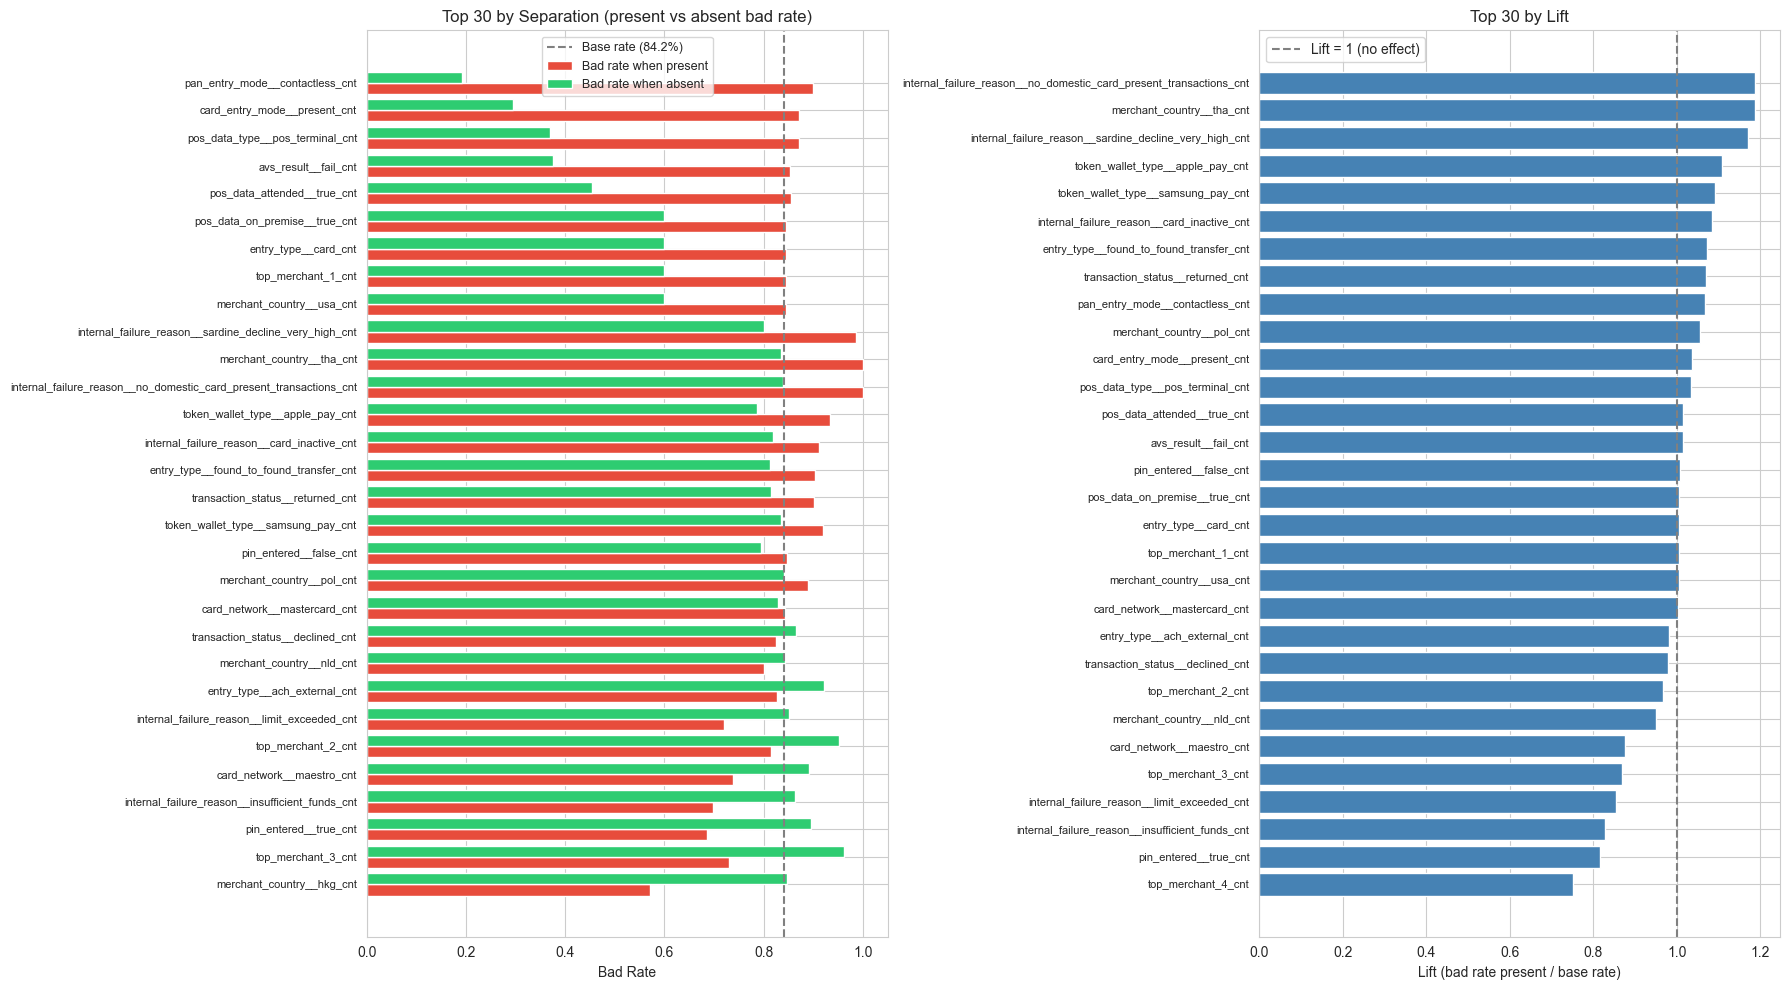

In [54]:
top30_sep  = univ.nlargest(30, "separation").sort_values("separation")
top30_lift = univ.nlargest(30, "lift").sort_values("lift")

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Left — bad rate present vs absent
y = np.arange(len(top30_sep))
axes[0].barh(y - 0.2, top30_sep["bad_rate_present"], 0.4,
             label="Bad rate when present", color="#e74c3c")
axes[0].barh(y + 0.2, top30_sep["bad_rate_absent"],  0.4,
             label="Bad rate when absent",  color="#2ecc71")
axes[0].axvline(base_rate, color="grey", linestyle="--",
                label=f"Base rate ({base_rate:.1%})")
axes[0].set_yticks(y)
axes[0].set_yticklabels(top30_sep["feature"], fontsize=8)
axes[0].set_xlabel("Bad Rate")
axes[0].set_title("Top 30 by Separation (present vs absent bad rate)")
axes[0].legend(fontsize=9)

# Right — lift
axes[1].barh(top30_lift["feature"], top30_lift["lift"], color="steelblue")
axes[1].axvline(1.0, color="grey", linestyle="--", label="Lift = 1 (no effect)")
axes[1].set_xlabel("Lift (bad rate present / base rate)")
axes[1].set_title("Top 30 by Lift")
axes[1].tick_params(axis="y", labelsize=8)
axes[1].legend()

plt.tight_layout()
plt.show()


In [55]:
def eval_rule(mask, label, name):
    tp = int((mask & label).sum())
    fp = int((mask & ~label).sum())
    fn = int((~mask & label).sum())
    tn = int((~mask & ~label).sum())
    prec = tp / (tp + fp) if tp + fp else 0
    rec  = tp / (tp + fn) if tp + fn else 0
    fpr  = fp / (fp + tn) if fp + tn else 0
    return {"rule": name, "flagged": tp + fp,
            "TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "precision": round(prec, 3), "recall": round(rec, 3),
            "FPR": round(fpr, 3),
            "bad_rate_flagged": round(tp / (tp + fp), 3) if tp + fp else 0}

bf = business_flat.copy()
label_s = bf["is_bad"].astype(bool)

# Derive rates from count columns
bf["atm_rate"]     = bf["entry_type__atm_cnt"]               / bf["n_transactions"]
bf["decline_rate"] = bf["transaction_status__declined_cnt"]  / bf["n_transactions"]
bf["cnp_rate"]     = bf["card_entry_mode__not_present_cnt"]  / bf["n_transactions"]
bf["avs_fail_rate"]= bf["avs_result__fail_cnt"] / bf["n_card_txns"].replace(0, np.nan)
bf["return_rate"]  = bf["transaction_status__returned_cnt"]  / bf["n_transactions"]
bf["insuf_flag"]   = bf["internal_failure_reason__insufficient_funds_cnt"] > 0
bf["inst_deb_rate"]= bf["entry_type__instant_debit_cnt"]     / bf["n_transactions"]

rule_A = bf["atm_rate"]     >= 0.10
rule_B = (bf["span_days"] <= 7) & (bf["decline_rate"] >= 0.20)
rule_C = (bf["cnp_rate"]   >= 0.60) & (bf["avs_fail_rate"].fillna(0) >= 0.50)
rule_D = bf["insuf_flag"]
rule_E = bf["inst_deb_rate"] >= 0.20
rule_F = bf["return_rate"]  >= 0.10
rule_combo = rule_A | rule_B | rule_C

rule_results = pd.DataFrame([
    eval_rule(rule_A,     label_s, "A: ATM >= 10% of txns"),
    eval_rule(rule_B,     label_s, "B: life <= 7d AND decline >= 20%"),
    eval_rule(rule_C,     label_s, "C: CNP >= 60% AND AVS fail >= 50%"),
    eval_rule(rule_D,     label_s, "D: any INSUFFICIENT_FUNDS"),
    eval_rule(rule_E,     label_s, "E: instant debit >= 20% of txns"),
    eval_rule(rule_F,     label_s, "F: return rate >= 10%"),
    eval_rule(rule_combo, label_s, "Combined: A | B | C"),
])
display(rule_results)


,rule,flagged,TP,FP,FN,TN,precision,recall,FPR,bad_rate_flagged
0,A: ATM >= 10% of txns,2,0,2,272,49,0.000,0.000,0.039,0.000
1,B: life <= 7d AND decline >= 20%,47,47,0,225,51,1.000,0.173,0.000,1.000
2,C: CNP >= 60% AND AVS fail >= 50%,6,3,3,269,48,0.500,0.011,0.059,0.500
3,D: any INSUFFICIENT_FUNDS,43,30,13,242,38,0.698,0.110,0.255,0.698
4,E: instant debit >= 20% of txns,1,0,1,272,50,0.000,0.000,0.020,0.000
5,F: return rate >= 10%,67,66,1,206,50,0.985,0.243,0.020,0.985
6,Combined: A | B | C,55,50,5,222,46,0.909,0.184,0.098,0.909


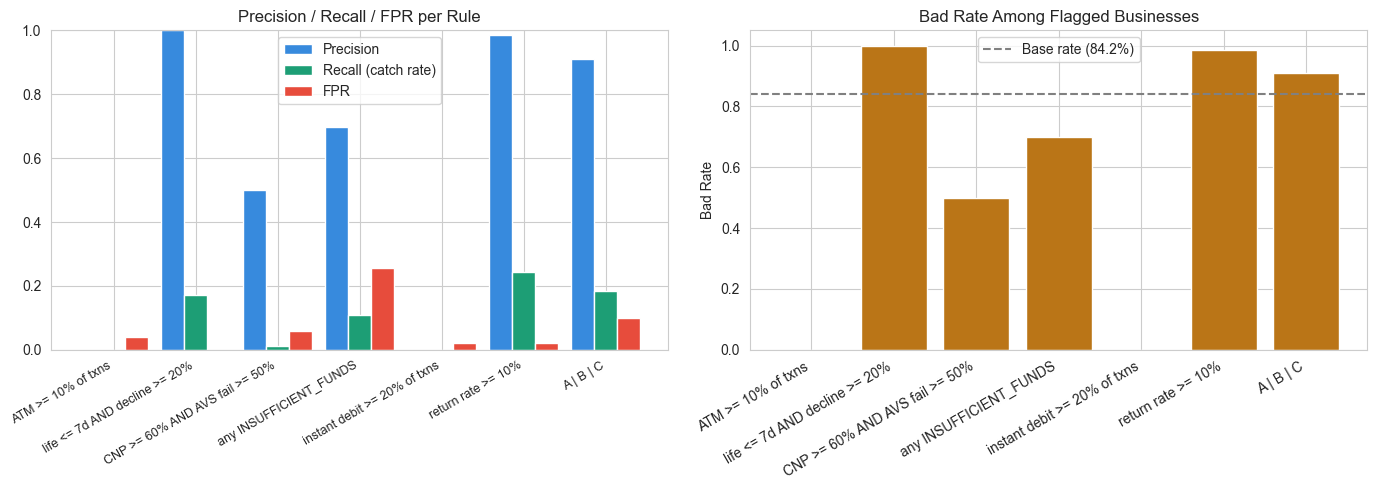

In [56]:
short_names = rule_results["rule"].str.replace(r"^[A-Za-z]+: ", "", regex=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x, w = np.arange(len(rule_results)), 0.28

axes[0].bar(x - w, rule_results["precision"], w, label="Precision",           color="#378ADD")
axes[0].bar(x,     rule_results["recall"],    w, label="Recall (catch rate)", color="#1D9E75")
axes[0].bar(x + w, rule_results["FPR"],       w, label="FPR",                color="#e74c3c")
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names, rotation=30, ha="right", fontsize=9)
axes[0].set_ylim(0, 1)
axes[0].set_title("Precision / Recall / FPR per Rule")
axes[0].legend()

axes[1].bar(short_names, rule_results["bad_rate_flagged"], color="#BA7517")
axes[1].axhline(base_rate, color="grey", linestyle="--",
                label=f"Base rate ({base_rate:.1%})")
axes[1].set_title("Bad Rate Among Flagged Businesses")
axes[1].set_ylabel("Bad Rate")
axes[1].tick_params(axis="x", rotation=30)
for tick in axes[1].get_xticklabels(): tick.set_ha("right")
axes[1].legend()

plt.tight_layout()
plt.show()


# MCC Bad Rate Analysis

For each `mcc_description`, compute the bad rate at the **business level**, counting only businesses where that MCC appeared **more than once**.
Filters out single-transaction noise; surfaces repeat-purchase categories with high fraud rates.


In [57]:
# Business × MCC occurrence counts
biz_mcc = (
    df_combined[df_combined["mcc_description"].notna()]
    .groupby(["business_token", "mcc_description"])
    .agg(cnt=("mcc_description", "size"), is_bad=("is_bad", "first"))
    .reset_index()
)

# Keep only MCC × business pairs with more than 1 occurrence
biz_mcc_multi = biz_mcc[biz_mcc["cnt"] > 1]

mcc_stats = (
    biz_mcc_multi
    .groupby("mcc_description")
    .agg(
        n_businesses       =("business_token", "nunique"),
        n_bad_businesses   =("is_bad", "sum"),
        avg_occurrences    =("cnt", "mean"),
        max_occurrences    =("cnt", "max"),
    )
    .reset_index()
)
mcc_stats["bad_rate"] = mcc_stats["n_bad_businesses"] / mcc_stats["n_businesses"]
mcc_stats = mcc_stats.sort_values("bad_rate", ascending=False).reset_index(drop=True)

print(f"MCC categories with >1 occurrence per business: {len(mcc_stats)}")
display(
    mcc_stats
    .rename(columns={
        "mcc_description": "MCC Description",
        "n_businesses": "# Businesses",
        "n_bad_businesses": "# Bad",
        "bad_rate": "Bad Rate",
        "avg_occurrences": "Avg Occurrences",
        "max_occurrences": "Max Occurrences",
    })
    .style.format({"Bad Rate": "{:.1%}", "Avg Occurrences": "{:.1f}"})
    .background_gradient(subset=["Bad Rate"], cmap="RdYlGn_r")
)


MCC categories with >1 occurrence per business: 145


,MCC Description,# Businesses,# Bad,Avg Occurrences,Max Occurrences,Bad Rate
0,Women’s Ready-to-Wear Stores,1,1,2.0,2,100.0%
1,"Sports Apparel, Riding Apparel Stores",1,1,3.0,3,100.0%
2,Women’s Accessory and Specialty Shops,20,20,2.9,7,100.0%
3,DOUBLETREE HOTELS,1,1,4.0,4,100.0%
4,Meat Provisioners – Freezer and Locker,1,1,5.0,5,100.0%
5,Car Rental Companies ( Not Listed Below),1,1,25.0,25,100.0%
6,"Local/Suburban Commuter Passenger Transportation – Railroads, Feries, Local Water Transportation.",1,1,16.0,16,100.0%
7,Men’s and Women’s Clothing Stores,172,164,4.3,22,95.3%
8,Postal Services – Government Only,36,30,2.6,10,83.3%
9,Drug Stores and Pharmacies,30,25,5.4,14,83.3%


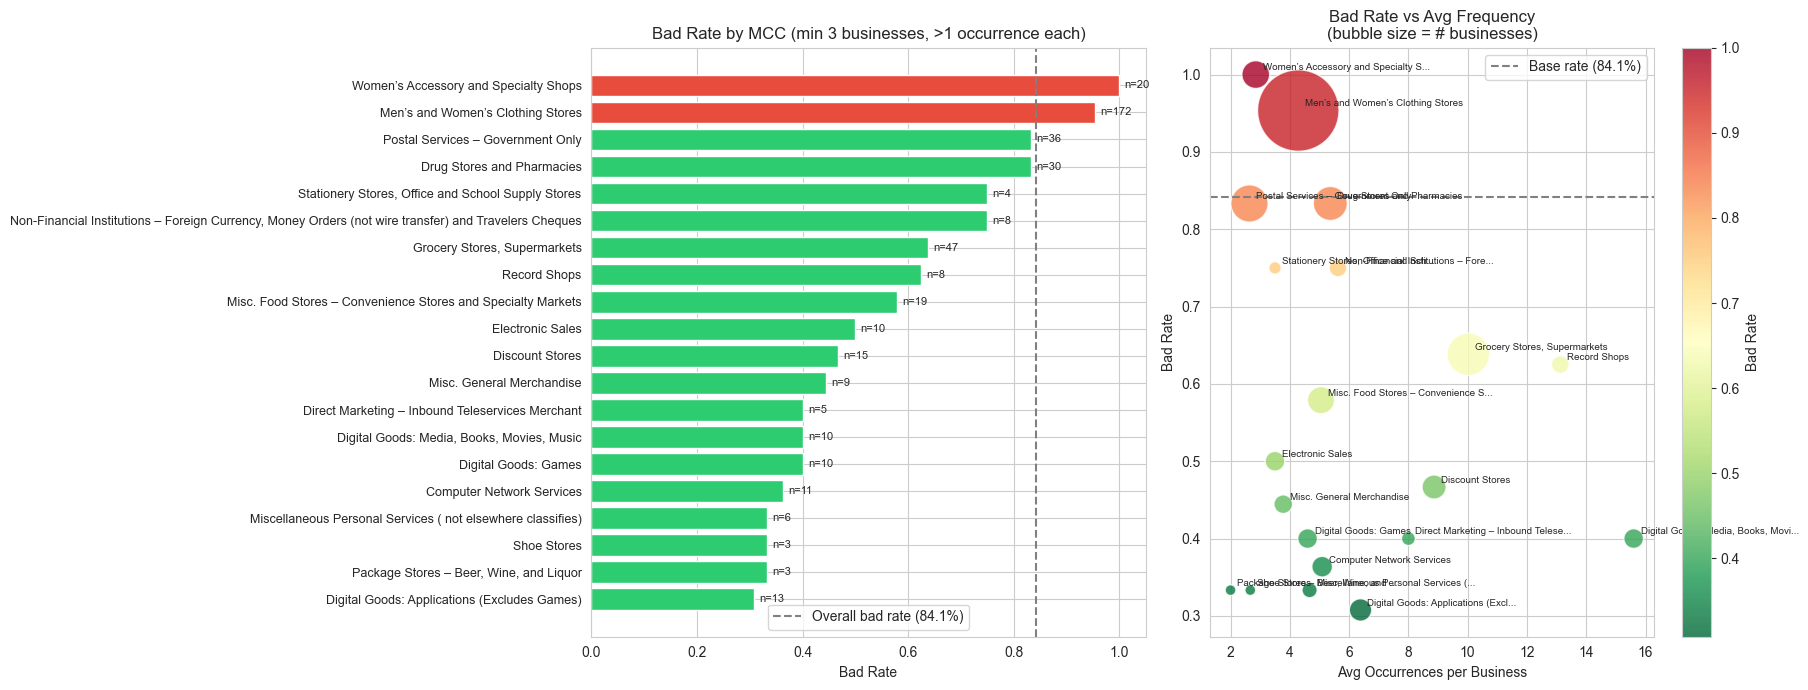


High-risk MCC categories (bad rate > 84.1%, n >= 3 businesses):


,MCC,n_businesses,n_bad_businesses,Bad Rate,Lift,Avg Occ
2,Women’s Accessory and Specialty Shops,20,20,100.0%,1.19x,2.9
7,Men’s and Women’s Clothing Stores,172,164,95.3%,1.13x,4.3


In [58]:
# ── Plot: top MCC categories by bad rate (min 3 businesses for stability) ──
base_rate = df_label["is_bad"].mean()

plot_df = (
    mcc_stats[mcc_stats["n_businesses"] >= 3]
    .nlargest(20, "bad_rate")
    .sort_values("bad_rate")
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left — bad rate bar chart
colors = ["#e74c3c" if r > base_rate else "#2ecc71" for r in plot_df["bad_rate"]]
bars = axes[0].barh(plot_df["mcc_description"], plot_df["bad_rate"], color=colors)
axes[0].axvline(base_rate, color="grey", linestyle="--",
                label=f"Overall bad rate ({base_rate:.1%})")
for bar, n in zip(bars, plot_df["n_businesses"]):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"n={n}", va="center", fontsize=8)
axes[0].set_xlabel("Bad Rate")
axes[0].set_title("Bad Rate by MCC (min 3 businesses, >1 occurrence each)")
axes[0].legend()
axes[0].tick_params(axis="y", labelsize=9)

# Right — bubble: bad rate vs avg occurrences, sized by n_businesses
sc = axes[1].scatter(
    plot_df["avg_occurrences"],
    plot_df["bad_rate"],
    s=plot_df["n_businesses"] * 20,
    c=plot_df["bad_rate"],
    cmap="RdYlGn_r",
    alpha=0.8,
    edgecolors="white",
)
for _, row in plot_df.iterrows():
    label = row["mcc_description"]
    # shorten long labels
    if len(label) > 35:
        label = label[:33] + "..."
    axes[1].annotate(label,
        (row["avg_occurrences"], row["bad_rate"]),
        textcoords="offset points", xytext=(5, 3), fontsize=7)
axes[1].axhline(base_rate, color="grey", linestyle="--",
                label=f"Base rate ({base_rate:.1%})")
axes[1].set_xlabel("Avg Occurrences per Business")
axes[1].set_ylabel("Bad Rate")
axes[1].set_title("Bad Rate vs Avg Frequency\n(bubble size = # businesses)")
axes[1].legend()
plt.colorbar(sc, ax=axes[1], label="Bad Rate")

plt.tight_layout()
plt.show()

# Summary table — high-signal categories (bad rate > base rate, n >= 3)
high_risk_mcc = mcc_stats[
    (mcc_stats["bad_rate"] > base_rate) & (mcc_stats["n_businesses"] >= 3)
].copy()
high_risk_mcc["lift"] = (high_risk_mcc["bad_rate"] / base_rate).round(2)
print(f"\nHigh-risk MCC categories (bad rate > {base_rate:.1%}, n >= 3 businesses):")
display(
    high_risk_mcc[["mcc_description","n_businesses","n_bad_businesses",
                   "bad_rate","lift","avg_occurrences"]]
    .rename(columns={"mcc_description": "MCC", "bad_rate": "Bad Rate",
                     "avg_occurrences": "Avg Occ", "lift": "Lift"})
    .style.format({"Bad Rate": "{:.1%}", "Lift": "{:.2f}x", "Avg Occ": "{:.1f}"})
    .background_gradient(subset=["Bad Rate"], cmap="RdYlGn_r")
)
